1. The basic setup of the experiment

In [2]:
# =====================================================================
# HYCO‑FL for elliptic PDE parameter identification
#   - Domain with irregular outer boundary and internal interface
#   - Two subdomains Ω₁ (inner) and Ω₂ (outer) with constant
#     coefficients a₁ and a₂ (true values [2.0, 1.0])
#   - Two clients: physical (uses FEM + data in Ω₁) and synthetic
#     (uses neural network + data in Ω₂), coupled via ghost points
#   - Federated averaging of coefficients and network parameters
#
# Enhancements added:
#   * Optional random resampling of ghost points each round
#   * Exponential learning rate decay for both optimisers
#   * Detailed English comments throughout
# =====================================================================

import time
import math
import copy
import pickle
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.tri as mtri

from scipy.spatial import Delaunay
from scipy.sparse import coo_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# ---------------------------------------------------------------------
# Reproducibility and device
# ---------------------------------------------------------------------
SEED = 1240
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float32)

# ---------------------------------------------------------------------
# Problem settings
# ---------------------------------------------------------------------
A_TRUE = np.array([2.0, 1.0])          # true coefficients [a1, a2]
A_INIT = np.array([0.5, 0.5])          # initial guess
A_MIN, A_MAX = 0.2, 5.0                # bounds (soft‑constrained via softplus)

NOISE_LEVELS = [0.00]       # can be extended [0.00, 0.05, 0.10, 0.15, 0.20]
PLOT_NOISE = 0.00

SAVE_DIR = "./results_elliptic2/"
os.makedirs(SAVE_DIR, exist_ok=True)

# Mesh and sampling sizes
FAST_MODE = True
if FAST_MODE:
    N_INTERIOR_MESH = 900
    N_OUTER_BDRY = 180
    N_INTERFACE = 160
    N_OBS_PHY = 800
    N_OBS_SYN = 800
    N_GHOST = 1000
    HYCO_ROUNDS = 20000
    HYCO_E_LOCAL = 2
    PINN_EPOCHS = 30000          # (unused here, kept for compatibility)
    XPINN_EPOCHS = 30000
    N_COLLOC_INNER = 600
    N_COLLOC_OUTER = 900
    N_BDRY = 300
    N_IFACE = 300
else:
    N_INTERIOR_MESH = 2500
    N_OUTER_BDRY = 360
    N_INTERFACE = 300
    N_OBS_PHY = 600
    N_OBS_SYN = 600
    N_GHOST = 1200
    HYCO_ROUNDS = 150
    HYCO_E_LOCAL = 2
    PINN_EPOCHS = 8000
    XPINN_EPOCHS = 8000
    N_COLLOC_INNER = 1500
    N_COLLOC_OUTER = 2500
    N_BDRY = 800
    N_IFACE = 800

# HYCO hyperparameters (initial learning rates)
ETA_PSI_INIT = 5e-3          # learning rate for coefficients (raw)
ETA_THETA_INIT = 8e-4        # learning rate for neural network parameters
ALPHA_PHY = 0.3
ALPHA_SYN = 0.2
BETA_PHY = 1e-8
BETA_SYN = 1e-8

# Learning rate decay settings
LR_DECAY_RATE = 0.9995       # multiply by this each round
LR_DECAY_STEP = 100            # Reduce the learning rate every 100 ROUNDS

# Ghost resampling option
RESAMPLE_GHOST_EACH_ROUND = True   # set True to enable per‑round resampling

print("Device:", DEVICE)
print("FAST_MODE:", FAST_MODE)
print("Resample ghosts each round:", RESAMPLE_GHOST_EACH_ROUND)

# =====================================================================
# Geometry definitions
# =====================================================================

def outer_radius(theta):
    """Outer boundary radius as function of polar angle."""
    return 1.0 + 0.12 * np.cos(3.0 * theta) + 0.08 * np.sin(5.0 * theta)

def interface_radius(theta):
    """Interface radius as function of polar angle."""
    return 0.42 * (1.0 + 0.22 * np.cos(5.0 * theta))

def polar_angle(x, y):
    return np.arctan2(y, x)

def polar_radius(x, y):
    return np.sqrt(x**2 + y**2)

def inside_outer_np(points, tol=1e-12):
    """Return boolean mask for points inside the outer boundary."""
    x, y = points[:, 0], points[:, 1]
    th = polar_angle(x, y)
    r = polar_radius(x, y)
    return r <= outer_radius(th) + tol

def inside_inner_np(points, tol=1e-12):
    """Return boolean mask for points inside the inner interface (Ω₁)."""
    x, y = points[:, 0], points[:, 1]
    th = polar_angle(x, y)
    r = polar_radius(x, y)
    return r <= interface_radius(th) + tol

def coefficient_region_np(points):
    """Return 1 for inside Ω₁, 2 for outside (Ω₂)."""
    return np.where(inside_inner_np(points), 1, 2)

def outer_boundary_points(n):
    """Equispaced points on the outer boundary."""
    th = np.linspace(0.0, 2.0*np.pi, n, endpoint=False)
    r = outer_radius(th)
    return np.column_stack([r*np.cos(th), r*np.sin(th)])

def interface_points_np(n):
    """Equispaced points on the interface."""
    th = np.linspace(0.0, 2.0*np.pi, n, endpoint=False)
    r = interface_radius(th)
    return np.column_stack([r*np.cos(th), r*np.sin(th)])

def interface_points_and_normals_np(n, eps=1e-5):
    """Points and outward normals on the interface."""
    th = np.linspace(0.0, 2.0*np.pi, n, endpoint=False)
    def gamma(theta):
        r = interface_radius(theta)
        return np.column_stack([r*np.cos(theta), r*np.sin(theta)])
    p_plus = gamma(th + eps)
    p_minus = gamma(th - eps)
    tangent = (p_plus - p_minus) / (2.0*eps)
    normal = np.column_stack([tangent[:,1], -tangent[:,0]])
    normal /= np.linalg.norm(normal, axis=1, keepdims=True) + 1e-14
    pts = gamma(th)
    # Ensure outward orientation
    orient = np.sum(normal * pts, axis=1)
    normal[orient < 0] *= -1.0
    return pts, normal

def sample_uniform_in_outer(n, seed=None):
    """Sample uniformly inside the outer domain (rejection sampling)."""
    rng = np.random.default_rng(seed)
    pts = []
    Rmax = 1.25
    while len(pts) < n:
        cand = rng.uniform(-Rmax, Rmax, size=(4*n, 2))
        mask = inside_outer_np(cand)
        accepted = cand[mask]
        pts.extend(list(accepted))
    return np.array(pts[:n])

def sample_uniform_in_inner(n, seed=None):
    """Sample uniformly inside Ω₁."""
    rng = np.random.default_rng(seed)
    pts = []
    Rmax = 0.65
    while len(pts) < n:
        cand = rng.uniform(-Rmax, Rmax, size=(4*n, 2))
        mask = inside_inner_np(cand)
        accepted = cand[mask]
        pts.extend(list(accepted))
    return np.array(pts[:n])

def sample_uniform_in_outer_shell(n, seed=None):
    """Sample uniformly in Ω₂ (outer shell)."""
    rng = np.random.default_rng(seed)
    pts = []
    Rmax = 1.25
    while len(pts) < n:
        cand = rng.uniform(-Rmax, Rmax, size=(5*n, 2))
        mask = inside_outer_np(cand) & (~inside_inner_np(cand))
        accepted = cand[mask]
        pts.extend(list(accepted))
    return np.array(pts[:n])

def sample_near_interface(n, width=0.055, seed=None):
    """Sample near the interface (Gaussian perturbation along normals)."""
    rng = np.random.default_rng(seed)
    pts, normals = interface_points_and_normals_np(max(n, 512))
    idx = rng.integers(0, len(pts), size=n)
    signed_dist = rng.normal(loc=0.0, scale=width, size=(n,1))
    cand = pts[idx] + signed_dist * normals[idx]
    # Ensure all points lie inside the outer domain
    mask = inside_outer_np(cand)
    if np.all(mask):
        return cand
    n_bad = np.sum(~mask)
    cand[~mask] = sample_uniform_in_outer(n_bad, seed=seed+999 if seed is not None else None)
    return cand

def sample_ghost_points(n, frac_near_interface=0.65, seed=None):
    """Mix of near‑interface and global points."""
    n_near = int(frac_near_interface * n)
    n_global = n - n_near
    pts_near = sample_near_interface(n_near, seed=seed)
    pts_global = sample_uniform_in_outer(n_global, seed=seed+1 if seed is not None else None)
    pts = np.vstack([pts_near, pts_global])
    np.random.default_rng(seed).shuffle(pts)
    return pts

# =====================================================================
# Unstructured mesh generation (FEM)
# =====================================================================

def build_unstructured_mesh(n_interior=1000, n_outer_boundary=180,
                            n_interface=160, seed=SEED):
    """
    Build a Delaunay mesh of the whole domain Ω.
    Returns points, triangles, and indices of Dirichlet boundary nodes.
    """
    rng = np.random.default_rng(seed)
    outer_pts = outer_boundary_points(n_outer_boundary)
    interface_pts = interface_points_np(n_interface)
    interior_pts = sample_uniform_in_outer(n_interior, seed=seed+10)
    points = np.vstack([outer_pts, interface_pts, interior_pts])
    points = np.unique(np.round(points, decimals=12), axis=0)
    delaunay = Delaunay(points)
    triangles_raw = delaunay.simplices.copy()
    # Keep only triangles whose centroid is inside Ω and with positive area
    centroids = points[triangles_raw].mean(axis=1)
    mask_centroid = inside_outer_np(centroids)
    p0 = points[triangles_raw[:,0]]
    p1 = points[triangles_raw[:,1]]
    p2 = points[triangles_raw[:,2]]
    areas = 0.5 * np.abs((p1[:,0]-p0[:,0])*(p2[:,1]-p0[:,1]) -
                         (p1[:,1]-p0[:,1])*(p2[:,0]-p0[:,0]))
    mask_area = areas > 1e-8
    triangles = triangles_raw[mask_centroid & mask_area]
    # Find boundary nodes (points lying on the outer boundary)
    th = polar_angle(points[:,0], points[:,1])
    r = polar_radius(points[:,0], points[:,1])
    boundary_mask = np.abs(r - outer_radius(th)) < 5e-6
    boundary_nodes = np.where(boundary_mask)[0]
    return points, triangles, boundary_nodes

# Build the mesh (will be used globally)
points, triangles, boundary_nodes = build_unstructured_mesh(
    n_interior=N_INTERIOR_MESH,
    n_outer_boundary=N_OUTER_BDRY,
    n_interface=N_INTERFACE,
    seed=SEED
)
triangulation = mtri.Triangulation(points[:,0], points[:,1], triangles)

print("Number of mesh nodes:", len(points))
print("Number of triangles:", len(triangles))
print("Number of Dirichlet boundary nodes:", len(boundary_nodes))

# =====================================================================
# FEM solvers (reference SciPy + differentiable PyTorch)
# =====================================================================

def source_np(x, y):
    """Right‑hand side f(x,y)."""
    return 1.0 + 0.5 * np.sin(np.pi * x) * np.cos(np.pi * y)

def assemble_fem_system(points, triangles, boundary_nodes, a_vec):
    """
    Assemble stiffness matrix and load vector for the given coefficients.
    Returns reduced system (free nodes only) and lumped mass matrix.
    """
    n_nodes = points.shape[0]
    rows, cols, vals = [], [], []
    rhs = np.zeros(n_nodes, dtype=np.float64)
    lumped_mass = np.zeros(n_nodes, dtype=np.float64)
    for tri in triangles:
        coords = points[tri]
        x0,y0 = coords[0]; x1,y1 = coords[1]; x2,y2 = coords[2]
        detJ = (x1-x0)*(y2-y0) - (x2-x0)*(y1-y0)
        area = 0.5 * abs(detJ)
        if area <= 1e-14:
            continue
        # Gradient of basis functions (b, c) where grad φ_i = (b_i, c_i)
        b = np.array([y1-y2, y2-y0, y0-y1]) / (2.0*area)
        c = np.array([x2-x1, x0-x2, x1-x0]) / (2.0*area)
        grads = np.column_stack([b, c])
        centroid = coords.mean(axis=0, keepdims=True)
        region = coefficient_region_np(centroid)[0]
        a = a_vec[0] if region == 1 else a_vec[1]
        local_K = a * area * (grads @ grads.T)
        xc, yc = centroid[0,0], centroid[0,1]
        local_F = source_np(xc, yc) * area / 3.0 * np.ones(3)
        for i_local, i_global in enumerate(tri):
            rhs[i_global] += local_F[i_local]
            lumped_mass[i_global] += area / 3.0
            for j_local, j_global in enumerate(tri):
                rows.append(i_global); cols.append(j_global)
                vals.append(local_K[i_local, j_local])
    K = coo_matrix((vals, (rows, cols)), shape=(n_nodes, n_nodes)).tocsr()
    all_nodes = np.arange(n_nodes)
    free_nodes = np.setdiff1d(all_nodes, boundary_nodes)
    K_ff = K[free_nodes][:, free_nodes]
    rhs_f = rhs[free_nodes]
    return K_ff, rhs_f, free_nodes, lumped_mass

def solve_fem(points, triangles, boundary_nodes, a_vec):
    """Solve the PDE with SciPy for given coefficients."""
    K_ff, rhs_f, free_nodes, lumped_mass = assemble_fem_system(
        points, triangles, boundary_nodes, a_vec)
    u = np.zeros(points.shape[0], dtype=np.float64)
    u[free_nodes] = spsolve(K_ff, rhs_f)
    return u

def make_interpolator(points, values):
    """
    Build an interpolator that uses linear interpolation and falls back
    to nearest neighbour for out‑of‑mesh points.
    """
    lin = LinearNDInterpolator(points, values, fill_value=np.nan)
    near = NearestNDInterpolator(points, values)
    def interp(xy):
        xy = np.asarray(xy)
        val = lin(xy)
        val = np.asarray(val)
        mask = np.isnan(val)
        if np.any(mask):
            val[mask] = near(xy[mask])
        return val
    return interp

def relative_l2_error_on_mesh(u_pred, u_ref, mass):
    """Weighted relative L² error using lumped mass matrix."""
    num = np.sqrt(np.sum(mass * (u_pred - u_ref)**2))
    den = np.sqrt(np.sum(mass * u_ref**2)) + 1e-14
    return num / den

# Compute reference solution using SciPy (fine mesh)
u_true = solve_fem(points, triangles, boundary_nodes, A_TRUE)
true_interp = make_interpolator(points, u_true)
_, _, _, lumped_mass = assemble_fem_system(points, triangles, boundary_nodes, A_TRUE)
print("Reference FEM solution computed.")
print("True a1, a2:", A_TRUE)

# ---------------------------------------------------------------------
# Differentiable PyTorch FEM (for training)
# ---------------------------------------------------------------------

def precompute_fem_real(points_np, triangles_np, boundary_nodes_np):
    """
    Pre‑compute all geometric quantities needed for the differentiable
    FEM assembly on the real mesh. Returns a dictionary of tensors.
    """
    nodes = torch.from_numpy(points_np.astype(np.float32)).to(DEVICE)
    triangles = torch.from_numpy(triangles_np.astype(np.int64)).to(DEVICE)
    boundary_mask = torch.zeros(len(nodes), dtype=torch.bool, device=DEVICE)
    boundary_mask[boundary_nodes_np] = True
    free_nodes = torch.where(~boundary_mask)[0]

    # Triangle geometry
    p = nodes[triangles]                         # (T,3,2)
    x1, y1 = p[:, 0, 0], p[:, 0, 1]
    x2, y2 = p[:, 1, 0], p[:, 1, 1]
    x3, y3 = p[:, 2, 0], p[:, 2, 1]
    area = 0.5 * torch.abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
    # Gradient basis functions (b,c) where grad φ_i = (b_i, c_i)
    b = torch.stack([y2 - y3, y3 - y1, y1 - y2], dim=1) / (2 * area.unsqueeze(1))
    c = torch.stack([x3 - x2, x1 - x3, x2 - x1], dim=1) / (2 * area.unsqueeze(1))
    centroid = p.mean(dim=1)                     # (T,2)
    # Region labels: 0 for inner (a1), 1 for outer (a2)
    centroid_np = centroid.cpu().numpy()
    region_labels_np = coefficient_region_np(centroid_np) - 1   # 0/1
    region_label = torch.from_numpy(region_labels_np.astype(np.int64)).to(DEVICE)

    return {
        'nodes': nodes,
        'triangles': triangles,
        'boundary_mask': boundary_mask,
        'free_nodes': free_nodes,
        'area': area,
        'b': b,
        'c': c,
        'centroid': centroid,
        'region_label': region_label,
        'n_nodes': len(nodes),
        'n_tri': len(triangles)
    }

fem_real = precompute_fem_real(points, triangles, boundary_nodes)

def build_interpolation_weights(triangulation, points_np, query_pts_np):
    """
    For each query point, find the triangle that contains it and compute
    barycentric weights for interpolation.
    Returns triangle indices and weights (both as torch tensors).
    """
    trifinder = triangulation.get_trifinder()
    tri_idx_raw = trifinder(query_pts_np[:,0], query_pts_np[:,1])
    n_q = len(query_pts_np)
    weights = np.zeros((n_q, 3), dtype=np.float32)
    tri_idx_fixed = np.copy(tri_idx_raw)
    triangles_np = triangulation.triangles

    for i in range(n_q):
        pt = query_pts_np[i]
        simp = tri_idx_raw[i]
        if simp == -1:   # fallback: nearest neighbour triangle
            dist = np.linalg.norm(points_np - pt, axis=1)
            nearest_node = np.argmin(dist)
            cand_tri = np.where(np.any(triangles_np == nearest_node, axis=1))[0]
            simp = cand_tri[0] if len(cand_tri) > 0 else 0
            tri_idx_fixed[i] = simp
        verts = points_np[triangles_np[simp]]
        v0 = verts[1] - verts[0]
        v1 = verts[2] - verts[0]
        v2 = pt - verts[0]
        d00 = np.dot(v0, v0)
        d01 = np.dot(v0, v1)
        d11 = np.dot(v1, v1)
        d20 = np.dot(v2, v0)
        d21 = np.dot(v2, v1)
        denom = d00 * d11 - d01 * d01
        if denom == 0:
            w = np.array([1/3, 1/3, 1/3])
        else:
            v = (d11 * d20 - d01 * d21) / denom
            w_param = (d00 * d21 - d01 * d20) / denom
            u = 1.0 - v - w_param
            w = np.array([u, v, w_param])
        w = np.clip(w, 0, 1)
        if w.sum() == 0:
            w = np.array([1/3, 1/3, 1/3])
        else:
            w /= w.sum()
        weights[i] = w

    tri_idx_tensor = torch.from_numpy(tri_idx_fixed.astype(np.int64)).to(DEVICE)
    weights_tensor = torch.from_numpy(weights).to(DEVICE)
    return tri_idx_tensor, weights_tensor

def interpolate_from_real_mesh(u, tri_idx, weights):
    """
    Interpolate nodal solution u (N_nodes,) to query points using
    pre‑computed triangle indices and barycentric weights.
    """
    tri_nodes = fem_real['triangles'][tri_idx]   # (N_q, 3)
    u_tri = u[tri_nodes]                         # (N_q, 3)
    return (u_tri * weights).sum(dim=1)

def assemble_K_torch_real(a1, a2):
    """Assemble the stiffness matrix for given coefficients (differentiable)."""
    n = fem_real['n_nodes']
    K = torch.zeros((n, n), device=DEVICE, dtype=torch.float32)
    area = fem_real['area']
    b = fem_real['b']
    c = fem_real['c']
    region = fem_real['region_label']   # 0→a1, 1→a2
    a = torch.where(region == 0, a1, a2)
    triangles = fem_real['triangles']
    for i in range(3):
        for j in range(3):
            val = a * area * (b[:, i] * b[:, j] + c[:, i] * c[:, j])
            idx_i = triangles[:, i]
            idx_j = triangles[:, j]
            K.index_put_((idx_i, idx_j), val, accumulate=True)
    return K

def assemble_F_torch_real():
    """Assemble the load vector (differentiable)."""
    nodes = fem_real['nodes']
    triangles = fem_real['triangles']
    centroid = fem_real['centroid']
    area = fem_real['area']
    xc, yc = centroid[:, 0], centroid[:, 1]
    f_val = 1.0 + 0.5 * torch.sin(np.pi * xc) * torch.cos(np.pi * yc)
    Fe = f_val * area / 3.0
    Fvec = torch.zeros(len(nodes), device=DEVICE, dtype=torch.float32)
    for i in range(3):
        Fvec.index_add_(0, triangles[:, i], Fe)
    return Fvec

def solve_pde_torch_real(a1, a2):
    """Solve the PDE with PyTorch FEM (differentiable)."""
    K = assemble_K_torch_real(a1, a2)
    Fvec = assemble_F_torch_real()
    free = fem_real['free_nodes']
    Kff = K[free][:, free]
    Ff = Fvec[free]
    uff = torch.linalg.solve(Kff, Ff)
    u = torch.zeros_like(Fvec)
    u[free] = uff
    return u

print("Differentiable FEM (real geometry) ready.")

# =====================================================================
# Observations and ghost points (generated once)
# =====================================================================

def generate_observations(noise_level, seed=SEED):
    """Generate noisy observations for both clients."""
    rng = np.random.default_rng(seed + 100)
    X_phy = sample_uniform_in_inner(N_OBS_PHY, seed=seed+101)
    X_syn = sample_uniform_in_outer_shell(N_OBS_SYN, seed=seed+102)
    y_phy_clean = true_interp(X_phy)
    y_syn_clean = true_interp(X_syn)
    if noise_level > 0:
        std_phy = np.std(y_phy_clean)
        std_syn = np.std(y_syn_clean)
        y_phy = y_phy_clean + noise_level * std_phy * rng.normal(size=y_phy_clean.shape)
        y_syn = y_syn_clean + noise_level * std_syn * rng.normal(size=y_syn_clean.shape)
    else:
        y_phy, y_syn = y_phy_clean, y_syn_clean
    return X_phy, y_phy, X_syn, y_syn

# Fixed observation sets (noise level 0 for demonstration)
X_phy, y_phy, X_syn, y_syn = generate_observations(0.0, seed=SEED)

# Fixed ghost and boundary points (unless resampling is enabled)
X_ghost = sample_ghost_points(N_GHOST, frac_near_interface=0.70, seed=SEED+103)
X_bdry = outer_boundary_points(N_BDRY)
y_bdry = np.zeros(len(X_bdry))

# Independent ghost test set for evaluation
X_ghost_test = sample_ghost_points(1000, frac_near_interface=0.70, seed=SEED+999)

# Pre‑compute interpolation weights for fixed sets (phy, syn, ghost, bdry, test)
def precompute_all_interpolation_weights():
    """Build interpolation weights for all fixed point sets."""
    interp_data = {}
    for name, pts in [('phy', X_phy), ('syn', X_syn), ('ghost', X_ghost),
                      ('bdry', X_bdry), ('ghost_test', X_ghost_test)]:
        tri_idx, w = build_interpolation_weights(triangulation, points, pts)
        interp_data[name] = {'tri_idx': tri_idx, 'weights': w, 'pts': pts}
    return interp_data

interp_cache = precompute_all_interpolation_weights()

# ------------------------------------------------------------
# Save dependency variables for later plotting
# ------------------------------------------------------------
dep_vars = {
    'A_TRUE': A_TRUE,
    'NOISE_LEVELS': NOISE_LEVELS,
    'PLOT_NOISE': PLOT_NOISE,
    'SAVE_DIR': SAVE_DIR,
    'points': points,
    'triangles': triangles,
    'u_true': u_true,
    'lumped_mass': lumped_mass,
    'inside_inner_np': inside_inner_np,
    'inside_outer_np': inside_outer_np,
    'outer_radius': outer_radius,
    'interface_radius': interface_radius,
    'relative_l2_error_on_mesh': relative_l2_error_on_mesh,
    'make_interpolator': make_interpolator,
    'solve_fem': solve_fem,
    'fem_real': fem_real,
    'interp_cache': interp_cache,
    'solve_pde_torch_real': solve_pde_torch_real,
    'interpolate_from_real_mesh': interpolate_from_real_mesh,
}
with open(os.path.join(SAVE_DIR, 'dep_vars.pkl'), 'wb') as f:
    pickle.dump(dep_vars, f)
print("Dependency variables saved to dep_vars.pkl.")

# =====================================================================
# Neural network utilities
# =====================================================================

def to_tensor(x, requires_grad=False):
    x = torch.tensor(x, dtype=torch.float32, device=DEVICE)
    x.requires_grad_(requires_grad)
    return x

class MLP(nn.Module):
    """Simple fully‑connected neural network with Tanh activation."""
    def __init__(self, in_dim=2, width=96, depth=4, out_dim=1, activation=nn.Tanh):
        super().__init__()
        layers = []
        layers.append(nn.Linear(in_dim, width))
        layers.append(activation())
        for _ in range(depth - 1):
            layers.append(nn.Linear(width, width))
            layers.append(activation())
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

def predict_nn_on_numpy(model, xy, batch_size=4096):
    """Evaluate neural network on a numpy array of points."""
    model.eval()
    outs = []
    with torch.no_grad():
        for i in range(0, len(xy), batch_size):
            xb = to_tensor(xy[i:i+batch_size])
            out = model(xb).cpu().numpy().reshape(-1)
            outs.append(out)
    return np.concatenate(outs)

def positive_psi(raw):
    """Softplus transformation to enforce positivity of coefficients."""
    return F.softplus(raw) + 1e-4

def softplus_inverse(x):
    """Inverse of softplus (for initialisation)."""
    if not isinstance(x, torch.Tensor):
        x = torch.tensor(x, dtype=torch.float32)
    else:
        x = x.detach().clone().requires_grad_(True)
    return torch.log(torch.expm1(x))

def source_torch(xy):
    """Source term f(x,y) as torch tensor."""
    x = xy[:,0:1]; y = xy[:,1:2]
    return 1.0 + 0.5 * torch.sin(np.pi * x) * torch.cos(np.pi * y)

def copy_model(model):
    """Create a copy of a neural network."""
    new_model = MLP(width=96, depth=4, activation=nn.Tanh).to(DEVICE)
    new_model.load_state_dict(model.state_dict())
    return new_model

def avg_models(model_a, model_b, wa=0.5, wb=0.5):
    """Weighted average of two network states."""
    m = copy_model(model_a)
    sd = m.state_dict()
    for k in sd:
        sd[k] = wa * model_a.state_dict()[k] + wb * model_b.state_dict()[k]
    m.load_state_dict(sd)
    return m

# =====================================================================
# HYCO training with federated aggregation
# =====================================================================

class HYCOResult:
    """Container for training results."""
    pass

def train_hyco(noise_level, agg_weight_phy=0.5,
               resample_ghost=RESAMPLE_GHOST_EACH_ROUND,
               lr_decay_rate=LR_DECAY_RATE,
               lr_decay_step=LR_DECAY_STEP,
               save=True):
    """
    HYCO‑FL training loop.

    Parameters:
        noise_level: standard deviation of added noise
        agg_weight_phy: weight for physical client during aggregation
        resample_ghost: if True, resample ghost points each round
        lr_decay_rate: multiplicative decay factor per decay step
        lr_decay_step: apply decay every this many rounds
        save: whether to pickle the result
    """
    # Generate noisy observations (only values depend on noise)
    X_phy, y_phy, X_syn, y_syn = generate_observations(noise_level, seed=SEED)

    # Fixed interpolation data for observations (never change)
    interp_phy = interp_cache['phy']
    interp_syn = interp_cache['syn']

    # Initial ghost points (will be overwritten if resampling)
    interp_ghost = interp_cache['ghost']   # dictionary with tri_idx, weights, pts
    X_ghost_t = to_tensor(interp_ghost['pts'])

    # Hyperparameters
    E_local = HYCO_E_LOCAL
    alpha_phy = ALPHA_PHY
    alpha_syn = ALPHA_SYN
    beta_phy = BETA_PHY
    beta_syn = BETA_SYN

    # Initialise coefficients (raw) and networks
    raw_phy = softplus_inverse(torch.tensor(A_INIT, dtype=torch.float32)).to(DEVICE).requires_grad_(True)
    raw_syn = softplus_inverse(torch.tensor(A_INIT, dtype=torch.float32)).to(DEVICE).requires_grad_(True)
    model_phy = MLP(width=96, depth=4, activation=nn.Tanh).to(DEVICE)
    model_syn = MLP(width=96, depth=4, activation=nn.Tanh).to(DEVICE)

    # Convert observation data to tensors
    X_phy_t = to_tensor(X_phy)
    X_syn_t = to_tensor(X_syn)
    y_phy_t = to_tensor(y_phy.reshape(-1,1))
    y_syn_t = to_tensor(y_syn.reshape(-1,1))

    # History logging
    history = {
        "round": [], "a1": [], "a2": [],
        "loss_phy": [], "loss_syn": [],
        "data_phy": [], "data_syn": [],
        "inter_phy": [], "inter_syn": []
    }

    tic = time.time()

    for m in range(HYCO_ROUNDS):
        # ---- (optional) resample ghost points ----
        if resample_ghost:
            # Use different seed each round to vary ghost positions
            seed_ghost = SEED + 103 + m
            X_ghost_new = sample_ghost_points(N_GHOST, frac_near_interface=0.70,
                                              seed=seed_ghost)
            # Recompute interpolation weights for the new ghost points
            tri_idx_new, weights_new = build_interpolation_weights(triangulation,
                                                                   points,
                                                                   X_ghost_new)
            interp_ghost = {
                'tri_idx': tri_idx_new,
                'weights': weights_new,
                'pts': X_ghost_new
            }
            X_ghost_t = to_tensor(X_ghost_new)

        # ---- Compute current learning rates with exponential decay ----
        decay_factor = lr_decay_rate ** (m // lr_decay_step)
        eta_psi = ETA_PSI_INIT * decay_factor
        eta_theta = ETA_THETA_INIT * decay_factor

        # ---- Physical client local update ----
        raw_phy_local = raw_phy.clone().detach().requires_grad_(True)
        model_phy_local = copy_model(model_phy)

        opt_phy_psi = optim.Adam([raw_phy_local], lr=eta_psi)
        opt_phy_theta = optim.Adam(model_phy_local.parameters(), lr=eta_theta,
                                   weight_decay=beta_syn)

        for _ in range(E_local):
            opt_phy_psi.zero_grad()
            opt_phy_theta.zero_grad()

            psi_phy = positive_psi(raw_phy_local)
            a1_phy, a2_phy = psi_phy[0], psi_phy[1]

            u_phy = solve_pde_torch_real(a1_phy, a2_phy)
            u_phy_obs = interpolate_from_real_mesh(u_phy, interp_phy['tri_idx'],
                                                   interp_phy['weights'])
            u_phy_ghost = interpolate_from_real_mesh(u_phy, interp_ghost['tri_idx'],
                                                     interp_ghost['weights'])

            us_ghost_phy = model_phy_local(X_ghost_t)[:, 0]

            loss_data_phy = torch.mean((u_phy_obs - y_phy_t.reshape(-1))**2)
            loss_inter_phy = torch.mean((u_phy_ghost - us_ghost_phy)**2)
            reg_phy = beta_phy * (a1_phy**2 + a2_phy**2)
            loss_phy = loss_data_phy + alpha_phy * loss_inter_phy + reg_phy

            loss_phy.backward()
            opt_phy_psi.step()
            opt_phy_theta.step()

        # ---- Synthetic client local update ----
        raw_syn_local = raw_syn.clone().detach().requires_grad_(True)
        model_syn_local = copy_model(model_syn)
        opt_syn_psi = optim.Adam([raw_syn_local], lr=eta_psi)
        opt_syn_theta = optim.Adam(model_syn_local.parameters(), lr=eta_theta,
                                   weight_decay=beta_syn)

        for _ in range(E_local):
            opt_syn_psi.zero_grad()
            opt_syn_theta.zero_grad()

            psi_syn = positive_psi(raw_syn_local)
            a1_syn, a2_syn = psi_syn[0], psi_syn[1]

            u_syn = solve_pde_torch_real(a1_syn, a2_syn)
            u_syn_obs = interpolate_from_real_mesh(u_syn, interp_syn['tri_idx'],
                                                   interp_syn['weights'])
            u_syn_ghost = interpolate_from_real_mesh(u_syn, interp_ghost['tri_idx'],
                                                     interp_ghost['weights'])

            us_syn_obs = model_syn_local(X_syn_t)[:, 0]
            us_syn_ghost = model_syn_local(X_ghost_t)[:, 0]

            loss_data_syn = torch.mean((us_syn_obs - y_syn_t.reshape(-1))**2)
            loss_inter_syn = torch.mean((us_syn_ghost - u_syn_ghost)**2)
            reg_syn = beta_syn * sum(p.pow(2).sum() for p in model_syn_local.parameters())
            loss_syn = loss_data_syn + alpha_syn * loss_inter_syn + reg_syn

            loss_syn.backward()
            opt_syn_psi.step()
            opt_syn_theta.step()

        # ---- Server aggregation ----
        agg_weight_syn = 1.0 - agg_weight_phy
        with torch.no_grad():
            raw_phy_new = agg_weight_phy * raw_phy_local + agg_weight_syn * raw_syn_local
            raw_syn_new = raw_phy_new.clone()   # both clients share the same coefficients
            raw_phy = raw_phy_new.clone().detach().requires_grad_(True)
            raw_syn = raw_phy.clone().detach().requires_grad_(True)

            model_phy = avg_models(model_phy_local, model_syn_local,
                                   agg_weight_phy, agg_weight_syn)
            model_syn = copy_model(model_phy)

        # ---- Logging ----
        psi_global = positive_psi(raw_phy)
        a1_global = psi_global[0].item()
        a2_global = psi_global[1].item()

        if (m % 500 == 0) or (m == HYCO_ROUNDS-1):
            with torch.no_grad():
                u_global = solve_pde_torch_real(psi_global[0], psi_global[1])
                u_phy_obs_val = interpolate_from_real_mesh(u_global,
                                                           interp_phy['tri_idx'],
                                                           interp_phy['weights'])
                u_syn_obs_val = interpolate_from_real_mesh(u_global,
                                                           interp_syn['tri_idx'],
                                                           interp_syn['weights'])
                loss_data_phy_val = torch.mean((u_phy_obs_val - y_phy_t.reshape(-1))**2).item()
                loss_data_syn_val = torch.mean((u_syn_obs_val - y_syn_t.reshape(-1))**2).item()
                u_ghost_val = interpolate_from_real_mesh(u_global,
                                                         interp_ghost['tri_idx'],
                                                         interp_ghost['weights'])
                us_ghost_val = model_phy(X_ghost_t)[:, 0]
                inter_loss_val = torch.mean((u_ghost_val - us_ghost_val)**2).item()

            history["round"].append(m)
            history["a1"].append(a1_global)
            history["a2"].append(a2_global)
            history["loss_phy"].append(loss_data_phy_val)
            history["loss_syn"].append(loss_data_syn_val)
            history["data_phy"].append(loss_data_phy_val)
            history["data_syn"].append(loss_data_syn_val)
            history["inter_phy"].append(inter_loss_val)
            history["inter_syn"].append(inter_loss_val)

            print(f"[HYCO-FL] round={m:04d} | a=({a1_global:.4f},{a2_global:.4f}) | "
                  f"loss_phy={loss_data_phy_val:.3e} loss_syn={loss_data_syn_val:.3e} "
                  f"loss_int={inter_loss_val:.3e} | lr={eta_psi:.2e}")

    toc = time.time()

    # ---- Final evaluation (using SciPy FEM on fine mesh) ----
    a_final = [a1_global, a2_global]
    u_phy_final = solve_fem(points, triangles, boundary_nodes, a_final)
    u_syn_final = predict_nn_on_numpy(model_phy, points)

    mask_inner = inside_inner_np(points)
    mask_outer = ~mask_inner
    mass_inner = lumped_mass[mask_inner]
    mass_outer = lumped_mass[mask_outer]

    e_phy_Omega = relative_l2_error_on_mesh(u_phy_final, u_true, lumped_mass)
    e_syn_Omega = relative_l2_error_on_mesh(u_syn_final, u_true, lumped_mass)
    e_phy_Omega1 = relative_l2_error_on_mesh(u_phy_final[mask_inner], u_true[mask_inner], mass_inner)
    e_phy_Omega2 = relative_l2_error_on_mesh(u_phy_final[mask_outer], u_true[mask_outer], mass_outer)
    e_syn_Omega1 = relative_l2_error_on_mesh(u_syn_final[mask_inner], u_true[mask_inner], mass_inner)
    e_syn_Omega2 = relative_l2_error_on_mesh(u_syn_final[mask_outer], u_true[mask_outer], mass_outer)
    Gap_phy = e_phy_Omega2 - e_phy_Omega1
    Gap_syn = e_syn_Omega1 - e_syn_Omega2

    interp_phy_final = make_interpolator(points, u_phy_final)
    y_phy_ghost_train = interp_phy_final(X_ghost)
    y_syn_ghost_train = predict_nn_on_numpy(model_phy, X_ghost)
    e_int_train = np.sqrt(np.mean((y_phy_ghost_train - y_syn_ghost_train)**2))
    y_phy_ghost_test = interp_phy_final(X_ghost_test)
    y_syn_ghost_test = predict_nn_on_numpy(model_phy, X_ghost_test)
    e_int_test = np.sqrt(np.mean((y_phy_ghost_test - y_syn_ghost_test)**2))

    # Interface flux and jump errors
    n_if = 500
    X_if, N_if = interface_points_and_normals_np(n_if)
    eps_if = 1e-4
    X_if_minus = X_if - eps_if * N_if
    X_if_plus  = X_if + eps_if * N_if
    u_phy_minus = interp_phy_final(X_if_minus)
    u_phy_plus  = interp_phy_final(X_if_plus)
    du_dn_phy = (u_phy_plus - u_phy_minus) / (2.0 * eps_if)
    a1, a2 = a_final
    flux_phy_inner = a1 * du_dn_phy
    flux_phy_outer = a2 * du_dn_phy
    jump_flux_phy = np.sqrt(np.mean((flux_phy_outer - flux_phy_inner)**2))

    u_syn_minus = predict_nn_on_numpy(model_phy, X_if_minus)
    u_syn_plus  = predict_nn_on_numpy(model_phy, X_if_plus)
    du_dn_syn = (u_syn_plus - u_syn_minus) / (2.0 * eps_if)
    flux_syn_inner = a1 * du_dn_syn
    flux_syn_outer = a2 * du_dn_syn
    jump_flux_syn = np.sqrt(np.mean((flux_syn_outer - flux_syn_inner)**2))

    u_phy_if = interp_phy_final(X_if)
    u_syn_if = predict_nn_on_numpy(model_phy, X_if)
    jump_u = np.sqrt(np.mean((u_phy_if - u_syn_if)**2))
    jump_u_phy = np.sqrt(np.mean((u_phy_plus - u_phy_minus)**2))
    jump_u_syn = np.sqrt(np.mean((u_syn_plus - u_syn_minus)**2))

    delta_a1 = abs(a1 - A_TRUE[0]) / A_TRUE[0]
    delta_a2 = abs(a2 - A_TRUE[1]) / A_TRUE[1]
    e_gamma = np.linalg.norm(np.array(a_final) - A_TRUE) / np.linalg.norm(A_TRUE)

    # Package results
    result = HYCOResult()
    result.a = np.array(a_final)
    result.u_phy = u_phy_final
    result.u_syn = u_syn_final
    result.history = history
    result.runtime = toc - tic
    result.e_phy_Omega = e_phy_Omega
    result.e_syn_Omega = e_syn_Omega
    result.e_phy_Omega1 = e_phy_Omega1
    result.e_phy_Omega2 = e_phy_Omega2
    result.e_syn_Omega1 = e_syn_Omega1
    result.e_syn_Omega2 = e_syn_Omega2
    result.Gap_phy = Gap_phy
    result.Gap_syn = Gap_syn
    result.e_int_train = e_int_train
    result.e_int_test = e_int_test
    result.jump_u = jump_u
    result.jump_u_phy = jump_u_phy
    result.jump_u_syn = jump_u_syn
    result.jump_flux_phy = jump_flux_phy
    result.jump_flux_syn = jump_flux_syn
    result.delta_a1 = delta_a1
    result.delta_a2 = delta_a2
    result.e_gamma = e_gamma

    # if save:
    #     filename_w = os.path.join(SAVE_DIR,
    #                               f"hyco_noise_{noise_level:.2f}_wphy_{agg_weight_phy:.2f}.pkl")
    #     with open(filename_w, 'wb') as f:
    #         pickle.dump(result, f)
    #     filename_std = os.path.join(SAVE_DIR, f"hyco_noise_{noise_level:.2f}.pkl")
    #     with open(filename_std, 'wb') as f:
    #         pickle.dump(result, f)
    #     print(f"HYCO result saved to {filename_w} and {filename_std}")

    # return result

    if save:
        filename_w = os.path.join(SAVE_DIR, f"hyco_noise_{noise_level:.2f}_wphy_{agg_weight_phy:.2f}.pkl")
        with open(filename_w, 'wb') as f:
            pickle.dump(result, f)
        if abs(agg_weight_phy - 0.5) < 1e-6:
            filename_std = os.path.join(SAVE_DIR, f"hyco_noise_{noise_level:.2f}.pkl")
            with open(filename_std, 'wb') as f:
                pickle.dump(result, f)
    return result

Device: cuda
FAST_MODE: True
Resample ghosts each round: True
Number of mesh nodes: 1240
Number of triangles: 2297
Number of Dirichlet boundary nodes: 180
Reference FEM solution computed.
True a1, a2: [2. 1.]
Differentiable FEM (real geometry) ready.
Dependency variables saved to dep_vars.pkl.


2. Robustness experiment to noise ⬇

In [1]:
# =====================================================================
# Main execution: run HYCO for each noise level
# =====================================================================

all_hyco_results = {}
for noise in NOISE_LEVELS:
    print(f"\n===== Training HYCO-FL with noise level η = {noise:.2f} =====")
    res = train_hyco(noise,
                     agg_weight_phy=0.5,
                     resample_ghost=RESAMPLE_GHOST_EACH_ROUND,
                     lr_decay_rate=LR_DECAY_RATE,
                     lr_decay_step=LR_DECAY_STEP,
                     save=True)
    all_hyco_results[noise] = res
    print(f"Runtime for noise {noise:.2f}: {res.runtime:.2f} seconds")
    print(f"Estimated a = {res.a}, true a = {A_TRUE}")

print("\nAll HYCO runs completed.")

Device: cuda
FAST_MODE: True
Resample ghosts each round: True
Number of mesh nodes: 1240
Number of triangles: 2297
Number of Dirichlet boundary nodes: 180
Reference FEM solution computed.
True a1, a2: [2. 1.]
Differentiable FEM (real geometry) ready.
Dependency variables saved to dep_vars.pkl.

===== Training HYCO-FL with noise level η = 0.00 =====
[HYCO-FL] round=0000 | a=(0.5040,0.5040) | loss_phy=4.971e-02 loss_syn=1.208e-02 loss_int=1.126e-01 | lr=5.00e-03
[HYCO-FL] round=0500 | a=(1.1382,1.1181) | loss_phy=1.434e-04 loss_syn=1.253e-04 loss_int=8.776e-04 | lr=4.99e-03
[HYCO-FL] round=1000 | a=(1.5327,1.0356) | loss_phy=1.260e-05 loss_syn=1.309e-05 loss_int=3.807e-04 | lr=4.98e-03
[HYCO-FL] round=1500 | a=(1.6341,1.0208) | loss_phy=4.576e-06 loss_syn=4.581e-06 loss_int=2.675e-04 | lr=4.96e-03
[HYCO-FL] round=2000 | a=(1.6532,1.0221) | loss_phy=4.934e-06 loss_syn=5.181e-06 loss_int=2.784e-04 | lr=4.95e-03
[HYCO-FL] round=2500 | a=(1.5996,1.0221) | loss_phy=5.354e-06 loss_syn=5.138e-0

3. Experiments with different weights ⬇

In [13]:
# ---- Weight（ η=0.20） ----
weight_list = [1.0, 0.75, 0.25, 0.0]
noise_level = 0.20
weight_results = {} 

for w in weight_list:
    print(f"\n===== Training HYCO-FL with noise η={noise_level:.2f}, weight_phy={w:.2f} =====")
    res = train_hyco(noise_level, agg_weight_phy=w, save=True)
    weight_results[w] = res
    print(f"Runtime for weight_phy={w:.2f}: {res.runtime:.2f} seconds")


===== Training HYCO-FL with noise η=0.20, weight_phy=1.00 =====
[HYCO-FL] round=0000 | a=(0.5040,0.5040) | loss_phy=4.973e-02 loss_syn=1.215e-02 loss_int=8.126e-02 | lr=5.00e-03
[HYCO-FL] round=0500 | a=(1.7602,1.0111) | loss_phy=8.809e-06 loss_syn=1.332e-04 loss_int=1.056e-03 | lr=4.99e-03
[HYCO-FL] round=1000 | a=(1.7530,1.0171) | loss_phy=1.025e-05 loss_syn=1.354e-04 loss_int=4.186e-04 | lr=4.98e-03
[HYCO-FL] round=1500 | a=(1.7443,1.0076) | loss_phy=9.422e-06 loss_syn=1.323e-04 loss_int=4.665e-04 | lr=4.96e-03
[HYCO-FL] round=2000 | a=(1.7726,1.0092) | loss_phy=8.641e-06 loss_syn=1.327e-04 loss_int=3.796e-04 | lr=4.95e-03
[HYCO-FL] round=2500 | a=(1.7238,1.0149) | loss_phy=9.568e-06 loss_syn=1.345e-04 loss_int=2.916e-04 | lr=4.94e-03
[HYCO-FL] round=3000 | a=(1.7511,1.0141) | loss_phy=9.274e-06 loss_syn=1.342e-04 loss_int=1.824e-04 | lr=4.93e-03
[HYCO-FL] round=3500 | a=(1.7503,1.0134) | loss_phy=9.137e-06 loss_syn=1.339e-04 loss_int=1.571e-04 | lr=4.91e-03
[HYCO-FL] round=4000 | 

4. PINN ⬇

In [3]:
# ============================================================
# Cell 8: PINN implementation (only once, noise=0.00)
# ============================================================

# ---- 添加所有必需的辅助函数（从原 Cell 6 提取） ----


def to_tensor(x, requires_grad=False):
    x = torch.tensor(x, dtype=torch.float32, device=DEVICE)
    x.requires_grad_(requires_grad)
    return x

def source_torch(xy):
    x = xy[:,0:1]; y = xy[:,1:2]
    return 1.0 + 0.5 * torch.sin(np.pi * x) * torch.cos(np.pi * y)

def derivatives_u_grad_lap(model, xy):
    """
    计算模型在 xy 处的 u, grad_u, laplacian(u)
    """
    xy = xy.clone().detach().requires_grad_(True)
    u = model(xy)
    grad_u = torch.autograd.grad(u, xy, grad_outputs=torch.ones_like(u),
                                  create_graph=True, retain_graph=True)[0]
    u_x = grad_u[:,0:1]; u_y = grad_u[:,1:2]
    u_xx = torch.autograd.grad(u_x, xy, grad_outputs=torch.ones_like(u_x),
                               create_graph=True, retain_graph=True)[0][:,0:1]
    u_yy = torch.autograd.grad(u_y, xy, grad_outputs=torch.ones_like(u_y),
                               create_graph=True, retain_graph=True)[0][:,1:2]
    lap = u_xx + u_yy
    return u, grad_u, lap

def inverse_softplus_np(y):
    y = np.asarray(y)
    return y + np.log(-np.expm1(-y))

def torch_positive_from_raw(raw):
    return torch.nn.functional.softplus(raw) + 1e-4

def predict_nn_on_numpy(model, xy, batch_size=4096):
    model.eval()
    outs = []
    with torch.no_grad():
        for i in range(0, len(xy), batch_size):
            xb = to_tensor(xy[i:i+batch_size])
            out = model(xb).cpu().numpy().reshape(-1)
            outs.append(out)
    return np.concatenate(outs)

# ---- 原有 PINN 代码 ----
class PINNResult:
    pass

class PINNModel(nn.Module):
    def __init__(self, width=96, depth=4):
        super().__init__()
        self.net = MLP(width=width, depth=depth, activation=nn.Tanh)
        raw_init = inverse_softplus_np(np.array([0.5, 0.5]))
        self.raw_a = nn.Parameter(torch.tensor(raw_init, dtype=torch.float32))
    def diffusion(self):
        return torch_positive_from_raw(self.raw_a)
    def forward(self, xy):
        return self.net(xy)

def train_pinn(noise_level=0.0, save=True):
    X_phy, y_phy, X_syn, y_syn = generate_observations(noise_level, seed=SEED)
    X_data = np.vstack([X_phy, X_syn])
    y_data = np.concatenate([y_phy, y_syn])
    X_data_t = to_tensor(X_data); y_data_t = to_tensor(y_data.reshape(-1,1))
    X_inner_col = sample_uniform_in_inner(N_COLLOC_INNER, seed=SEED+301)
    X_outer_col = sample_uniform_in_outer_shell(N_COLLOC_OUTER, seed=SEED+302)
    X_inner_col_t = to_tensor(X_inner_col)
    X_outer_col_t = to_tensor(X_outer_col)
    X_bdry_t = to_tensor(X_bdry); y_bdry_t = to_tensor(y_bdry.reshape(-1,1))
    X_if, N_if = interface_points_and_normals_np(N_IFACE)
    eps_if = 0.01
    X_if_minus = X_if - eps_if * N_if
    X_if_plus = X_if + eps_if * N_if
    X_if_minus_t = to_tensor(X_if_minus)
    X_if_plus_t = to_tensor(X_if_plus)
    N_if_t = to_tensor(N_if)

    model = PINNModel(width=96, depth=4).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    history = {"epoch":[], "a1":[], "a2":[], "loss":[], "rel_l2":[]}
    tic = time.time()
    for epoch in range(PINN_EPOCHS+1):
        optimizer.zero_grad()
        a = model.diffusion(); a1=a[0]; a2=a[1]
        u_data = model(X_data_t)
        loss_data = torch.mean((u_data - y_data_t)**2)
        _, _, lap_inner = derivatives_u_grad_lap(model, X_inner_col_t)
        f_inner = source_torch(X_inner_col_t)
        res_inner = -a1*lap_inner - f_inner
        loss_pde_inner = torch.mean(res_inner**2)
        _, _, lap_outer = derivatives_u_grad_lap(model, X_outer_col_t)
        f_outer = source_torch(X_outer_col_t)
        res_outer = -a2*lap_outer - f_outer
        loss_pde_outer = torch.mean(res_outer**2)
        loss_pde = loss_pde_inner + loss_pde_outer
        u_bdry = model(X_bdry_t)
        loss_bdry = torch.mean((u_bdry - y_bdry_t)**2)
        u_minus, grad_minus, _ = derivatives_u_grad_lap(model, X_if_minus_t)
        u_plus, grad_plus, _ = derivatives_u_grad_lap(model, X_if_plus_t)
        flux_minus = a1 * torch.sum(grad_minus * N_if_t, dim=1, keepdim=True)
        flux_plus = a2 * torch.sum(grad_plus * N_if_t, dim=1, keepdim=True)
        loss_if_u = torch.mean((u_minus - u_plus)**2)
        loss_if_flux = torch.mean((flux_minus - flux_plus)**2)
        loss = (10.0*loss_data + 1.0*loss_pde + 10.0*loss_bdry + 5.0*loss_if_u + 1.0*loss_if_flux)
        loss.backward()
        optimizer.step()
        if (epoch % 250 == 0) or (epoch == PINN_EPOCHS):
            u_nodes = predict_nn_on_numpy(model, points)
            err = relative_l2_error_on_mesh(u_nodes, u_true, lumped_mass)
            a_np = model.diffusion().detach().cpu().numpy()
            history["epoch"].append(epoch); history["a1"].append(a_np[0]); history["a2"].append(a_np[1])
            history["loss"].append(float(loss.detach().cpu().item())); history["rel_l2"].append(err)
            print(f"[PINN] epoch={epoch:05d} | a=({a_np[0]:.4f},{a_np[1]:.4f}) | L2={err:.3e}")
    toc = time.time()
    result = PINNResult()
    result.model = model
    result.a = model.diffusion().detach().cpu().numpy()
    result.u = predict_nn_on_numpy(model, points)
    result.history = history
    result.runtime = toc - tic
    if save:
        filename = os.path.join(SAVE_DIR, f"pinn_noise_{noise_level:.2f}.pkl")
        with open(filename, 'wb') as f:
            pickle.dump(result, f)
        print(f"PINN result saved to {filename}")
    return result

pinn_result = train_pinn(0.00, save=True)
print("PINN finished.")

[PINN] epoch=00000 | a=(0.5005,0.4997) | L2=8.964e-01
[PINN] epoch=00250 | a=(0.5978,0.6164) | L2=3.802e-01
[PINN] epoch=00500 | a=(0.6907,0.6871) | L2=2.845e-01
[PINN] epoch=00750 | a=(0.7709,0.7483) | L2=2.178e-01
[PINN] epoch=01000 | a=(0.8389,0.8026) | L2=1.660e-01
[PINN] epoch=01250 | a=(0.8930,0.8527) | L2=1.271e-01
[PINN] epoch=01500 | a=(0.9364,0.8974) | L2=9.839e-02
[PINN] epoch=01750 | a=(0.9716,0.9359) | L2=1.086e-01
[PINN] epoch=02000 | a=(1.0009,0.9687) | L2=6.401e-02
[PINN] epoch=02250 | a=(1.0244,0.9959) | L2=5.576e-02
[PINN] epoch=02500 | a=(1.0428,1.0181) | L2=5.070e-02
[PINN] epoch=02750 | a=(1.0573,1.0354) | L2=4.902e-02
[PINN] epoch=03000 | a=(1.0676,1.0485) | L2=4.479e-02
[PINN] epoch=03250 | a=(1.0751,1.0577) | L2=4.856e-02
[PINN] epoch=03500 | a=(1.0800,1.0637) | L2=4.871e-02
[PINN] epoch=03750 | a=(1.0827,1.0674) | L2=1.273e-01
[PINN] epoch=04000 | a=(1.0844,1.0693) | L2=4.914e-02
[PINN] epoch=04250 | a=(1.0845,1.0699) | L2=4.978e-02
[PINN] epoch=04500 | a=(1.08

5. XPINN ⬇

In [4]:
# ============================================================
# Cell 9: XPINN implementation (only once, noise=0.00)
# ============================================================

class XPINNResult:
    pass

class XPINNModel(nn.Module):
    def __init__(self, width=80, depth=4):
        super().__init__()
        self.net_inner = MLP(width=width, depth=depth, activation=nn.Tanh)
        self.net_outer = MLP(width=width, depth=depth, activation=nn.Tanh)
        raw_init = inverse_softplus_np(np.array([0.5, 0.5]))
        self.raw_a = nn.Parameter(torch.tensor(raw_init, dtype=torch.float32))
    def diffusion(self):
        return torch_positive_from_raw(self.raw_a)
    def forward_inner(self, xy):
        return self.net_inner(xy)
    def forward_outer(self, xy):
        return self.net_outer(xy)

def predict_xpinn_on_numpy(model, xy, batch_size=4096):
    model.eval()
    xy = np.asarray(xy)
    mask_inner = inside_inner_np(xy)
    out = np.zeros(len(xy), dtype=np.float64)
    if np.any(mask_inner):
        out[mask_inner] = predict_nn_on_numpy(model.net_inner, xy[mask_inner], batch_size=batch_size)
    if np.any(~mask_inner):
        out[~mask_inner] = predict_nn_on_numpy(model.net_outer, xy[~mask_inner], batch_size=batch_size)
    return out

def train_xpinn(noise_level=0.0, save=True):
    X_phy, y_phy, X_syn, y_syn = generate_observations(noise_level, seed=SEED)
    X_phy_t = to_tensor(X_phy); y_phy_t = to_tensor(y_phy.reshape(-1,1))
    X_syn_t = to_tensor(X_syn); y_syn_t = to_tensor(y_syn.reshape(-1,1))
    X_inner_col = sample_uniform_in_inner(N_COLLOC_INNER, seed=SEED+401)
    X_outer_col = sample_uniform_in_outer_shell(N_COLLOC_OUTER, seed=SEED+402)
    X_inner_col_t = to_tensor(X_inner_col)
    X_outer_col_t = to_tensor(X_outer_col)
    X_bdry_t = to_tensor(X_bdry); y_bdry_t = to_tensor(y_bdry.reshape(-1,1))
    X_if, N_if = interface_points_and_normals_np(N_IFACE)
    X_if_t = to_tensor(X_if); N_if_t = to_tensor(N_if)

    model = XPINNModel(width=80, depth=4).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    history = {"epoch":[], "a1":[], "a2":[], "loss":[], "rel_l2":[]}
    tic = time.time()
    for epoch in range(XPINN_EPOCHS+1):
        optimizer.zero_grad()
        a = model.diffusion(); a1=a[0]; a2=a[1]
        u_phy_pred = model.forward_inner(X_phy_t)
        u_syn_pred = model.forward_outer(X_syn_t)
        loss_data_inner = torch.mean((u_phy_pred - y_phy_t)**2)
        loss_data_outer = torch.mean((u_syn_pred - y_syn_t)**2)
        loss_data = loss_data_inner + loss_data_outer
        _, _, lap_inner = derivatives_u_grad_lap(model.net_inner, X_inner_col_t)
        f_inner = source_torch(X_inner_col_t)
        res_inner = -a1*lap_inner - f_inner
        loss_pde_inner = torch.mean(res_inner**2)
        _, _, lap_outer = derivatives_u_grad_lap(model.net_outer, X_outer_col_t)
        f_outer = source_torch(X_outer_col_t)
        res_outer = -a2*lap_outer - f_outer
        loss_pde_outer = torch.mean(res_outer**2)
        loss_pde = loss_pde_inner + loss_pde_outer
        u_bdry = model.forward_outer(X_bdry_t)
        loss_bdry = torch.mean((u_bdry - y_bdry_t)**2)
        u_if_inner, grad_if_inner, _ = derivatives_u_grad_lap(model.net_inner, X_if_t)
        u_if_outer, grad_if_outer, _ = derivatives_u_grad_lap(model.net_outer, X_if_t)
        flux_inner = a1 * torch.sum(grad_if_inner * N_if_t, dim=1, keepdim=True)
        flux_outer = a2 * torch.sum(grad_if_outer * N_if_t, dim=1, keepdim=True)
        loss_if_u = torch.mean((u_if_inner - u_if_outer)**2)
        loss_if_flux = torch.mean((flux_inner - flux_outer)**2)
        loss = (10.0*loss_data + 1.0*loss_pde + 10.0*loss_bdry + 10.0*loss_if_u + 2.0*loss_if_flux)
        loss.backward()
        optimizer.step()
        if (epoch % 250 == 0) or (epoch == XPINN_EPOCHS):
            u_nodes = predict_xpinn_on_numpy(model, points)
            err = relative_l2_error_on_mesh(u_nodes, u_true, lumped_mass)
            a_np = model.diffusion().detach().cpu().numpy()
            history["epoch"].append(epoch); history["a1"].append(a_np[0]); history["a2"].append(a_np[1])
            history["loss"].append(float(loss.detach().cpu().item())); history["rel_l2"].append(err)
            print(f"[XPINN] epoch={epoch:05d} | a=({a_np[0]:.4f},{a_np[1]:.4f}) | L2={err:.3e}")
    toc = time.time()
    result = XPINNResult()
    result.model = model
    result.a = model.diffusion().detach().cpu().numpy()
    result.u = predict_xpinn_on_numpy(model, points)
    result.history = history
    result.runtime = toc - tic
    if save:
        filename = os.path.join(SAVE_DIR, f"xpinn_noise_{noise_level:.2f}.pkl")
        with open(filename, 'wb') as f:
            pickle.dump(result, f)
        print(f"XPINN result saved to {filename}")
    return result

xpinn_result = train_xpinn(0.00, save=True)
print("XPINN finished.")

[XPINN] epoch=00000 | a=(0.4997,0.4997) | L2=8.841e-01
[XPINN] epoch=00250 | a=(0.5750,0.6111) | L2=2.047e-01
[XPINN] epoch=00500 | a=(0.6310,0.6814) | L2=1.651e-01
[XPINN] epoch=00750 | a=(0.6744,0.7497) | L2=1.285e-01
[XPINN] epoch=01000 | a=(0.7170,0.8141) | L2=1.069e-01
[XPINN] epoch=01250 | a=(0.7596,0.8726) | L2=9.115e-02
[XPINN] epoch=01500 | a=(0.8003,0.9239) | L2=7.606e-02
[XPINN] epoch=01750 | a=(0.8403,0.9666) | L2=6.558e-02
[XPINN] epoch=02000 | a=(0.8770,1.0004) | L2=5.755e-02
[XPINN] epoch=02250 | a=(0.9125,1.0253) | L2=5.384e-02
[XPINN] epoch=02500 | a=(0.9453,1.0431) | L2=5.085e-02
[XPINN] epoch=02750 | a=(0.9777,1.0546) | L2=4.964e-02
[XPINN] epoch=03000 | a=(1.0082,1.0610) | L2=4.910e-02
[XPINN] epoch=03250 | a=(1.0373,1.0644) | L2=4.823e-02
[XPINN] epoch=03500 | a=(1.0671,1.0648) | L2=4.517e-02
[XPINN] epoch=03750 | a=(1.0956,1.0635) | L2=4.356e-02
[XPINN] epoch=04000 | a=(1.1215,1.0613) | L2=6.563e-02
[XPINN] epoch=04250 | a=(1.1483,1.0594) | L2=4.065e-02
[XPINN] ep

6. Basic settings before drawing pictures

In [2]:
# =====================================================================
# Code Block A: Global initialization for all plotting cells
# Run this block once before any plotting cell.
# =====================================================================

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.tri as mtri
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
import torch

# ---------------------------------------------------------------------
# 1. Set the save directory (must match the training directory)
# ---------------------------------------------------------------------
SAVE_DIR = "./results_elliptic2/"

# ---------------------------------------------------------------------
# 2. Define all geometry and helper functions that are referenced in dep_vars.pkl
#    (These must be defined BEFORE loading dep_vars.pkl)
# ---------------------------------------------------------------------

def outer_radius(theta):
    return 1.0 + 0.12 * np.cos(3.0 * theta) + 0.08 * np.sin(5.0 * theta)

def interface_radius(theta):
    return 0.42 * (1.0 + 0.22 * np.cos(5.0 * theta))

def polar_angle(x, y):
    return np.arctan2(y, x)

def polar_radius(x, y):
    return np.sqrt(x**2 + y**2)

def inside_outer_np(points, tol=1e-12):
    x, y = points[:, 0], points[:, 1]
    th = polar_angle(x, y)
    r = polar_radius(x, y)
    return r <= outer_radius(th) + tol

def inside_inner_np(points, tol=1e-12):
    x, y = points[:, 0], points[:, 1]
    th = polar_angle(x, y)
    r = polar_radius(x, y)
    return r <= interface_radius(th) + tol

def coefficient_region_np(points):
    return np.where(inside_inner_np(points), 1, 2)

def outer_boundary_points(n):
    th = np.linspace(0.0, 2.0*np.pi, n, endpoint=False)
    r = outer_radius(th)
    return np.column_stack([r*np.cos(th), r*np.sin(th)])

def interface_points_np(n):
    th = np.linspace(0.0, 2.0*np.pi, n, endpoint=False)
    r = interface_radius(th)
    return np.column_stack([r*np.cos(th), r*np.sin(th)])

def interface_points_and_normals_np(n, eps=1e-5):
    th = np.linspace(0.0, 2.0*np.pi, n, endpoint=False)
    def gamma(theta):
        r = interface_radius(theta)
        return np.column_stack([r*np.cos(theta), r*np.sin(theta)])
    p_plus = gamma(th + eps)
    p_minus = gamma(th - eps)
    tangent = (p_plus - p_minus) / (2.0*eps)
    normal = np.column_stack([tangent[:,1], -tangent[:,0]])
    normal /= np.linalg.norm(normal, axis=1, keepdims=True) + 1e-14
    pts = gamma(th)
    orient = np.sum(normal * pts, axis=1)
    normal[orient < 0] *= -1.0
    return pts, normal

def make_interpolator(points, values):
    lin = LinearNDInterpolator(points, values, fill_value=np.nan)
    near = NearestNDInterpolator(points, values)
    def interp(xy):
        xy = np.asarray(xy)
        val = lin(xy)
        val = np.asarray(val)
        mask = np.isnan(val)
        if np.any(mask):
            val[mask] = near(xy[mask])
        return val
    return interp

def relative_l2_error_on_mesh(u_pred, u_ref, mass):
    num = np.sqrt(np.sum(mass * (u_pred - u_ref)**2))
    den = np.sqrt(np.sum(mass * u_ref**2)) + 1e-14
    return num / den

def solve_fem(points, triangles, boundary_nodes, a_vec):
    from scipy.sparse.linalg import spsolve
    from scipy.sparse import coo_matrix, csr_matrix
    print("Warning: solve_fem called (dummy).")
    return np.zeros(points.shape[0])

def source_np(x, y):
    return 1.0 + 0.5 * np.sin(np.pi * x) * np.cos(np.pi * y)

# ---------------------------------------------------------------------
# 3. Define placeholder functions for PyTorch FEM functions
#    (These are stored in dep_vars.pkl but never called in plotting)
# ---------------------------------------------------------------------

def solve_pde_torch_real(a1, a2):
    return torch.zeros(10)

def interpolate_from_real_mesh(u, tri_idx, weights):
    return torch.zeros(len(tri_idx))

def assemble_K_torch_real(a1, a2):
    return torch.zeros((10, 10))

def assemble_F_torch_real():
    return torch.zeros(10)

def precompute_fem_real(points_np, triangles_np, boundary_nodes_np):
    return {'dummy': 0}

def build_interpolation_weights(triangulation, points_np, query_pts_np):
    n_q = len(query_pts_np)
    return torch.zeros(n_q, dtype=torch.int64), torch.zeros((n_q, 3))

def derivatives_u_grad_lap(model, xy):
    return torch.zeros(len(xy), 1), torch.zeros((len(xy), 2)), torch.zeros(len(xy), 1)

def to_tensor(x, requires_grad=False):
    return torch.tensor(x, dtype=torch.float32)

def positive_psi(raw):
    return torch.nn.functional.softplus(raw) + 1e-4

def softplus_inverse(x):
    if not isinstance(x, torch.Tensor):
        x = torch.tensor(x, dtype=torch.float32)
    return torch.log(torch.expm1(x))

def predict_nn_on_numpy(model, xy, batch_size=4096):
    return np.zeros(len(xy))

# ---------------------------------------------------------------------
# 4. Load all dependency variables (mesh, reference solution, etc.)
# ---------------------------------------------------------------------
try:
    with open(os.path.join(SAVE_DIR, 'dep_vars.pkl'), 'rb') as f:
        dep = pickle.load(f)
        for k, v in dep.items():
            globals()[k] = v
    print("Loaded dependencies from dep_vars.pkl.")
except FileNotFoundError:
    print(f"ERROR: dep_vars.pkl not found in {SAVE_DIR}. Please run training cells first.")
    raise

# ---------- 关键修复：重建 triangulation（因为 dep_vars.pkl 中没有保存它） ----------
triangulation = mtri.Triangulation(points[:,0], points[:,1], triangles)
print("triangulation reconstructed.")

# ---------------------------------------------------------------------
# 5. Define empty classes for unpickling results
# ---------------------------------------------------------------------
class HYCOResult: pass
class PINNResult: pass
class XPINNResult: pass
class PINNModel: pass
class XPINNModel: pass
class MLP: pass

# ---------------------------------------------------------------------
# 6. Helper function to load result files
# ---------------------------------------------------------------------
def load_result(method, noise_level, weight=None):
    if weight is not None:
        filename = os.path.join(SAVE_DIR, f"{method}_noise_{noise_level:.2f}_wphy_{weight:.2f}.pkl")
    else:
        filename = os.path.join(SAVE_DIR, f"{method}_noise_{noise_level:.2f}.pkl")
    with open(filename, 'rb') as f:
        return pickle.load(f)

# ---------------------------------------------------------------------
# 7. Common plotting helper: overlay domain boundaries
# ---------------------------------------------------------------------
def overlay_boundaries(ax, lw=1.0, alpha=0.85, color='black'):
    th = np.linspace(0, 2*np.pi, 1000)
    outer = np.column_stack([outer_radius(th)*np.cos(th), outer_radius(th)*np.sin(th)])
    inner = np.column_stack([interface_radius(th)*np.cos(th), interface_radius(th)*np.sin(th)])
    ax.plot(outer[:,0], outer[:,1], color=color, lw=lw, alpha=alpha)
    ax.plot(inner[:,0], inner[:,1], color=color, lw=lw, alpha=alpha)

# ---------------------------------------------------------------------
# 8. Helper: compute interface jumps for arbitrary solution
# ---------------------------------------------------------------------
def compute_jumps(u_pred, a1, a2, points, eps_if=1e-4, n_if=500):
    X_if, N_if = interface_points_and_normals_np(n_if)
    X_if_minus = X_if - eps_if * N_if
    X_if_plus  = X_if + eps_if * N_if
    interp = make_interpolator(points, u_pred)
    u_minus = interp(X_if_minus)
    u_plus  = interp(X_if_plus)
    du_dn = (u_plus - u_minus) / (2.0 * eps_if)
    flux_inner = a1 * du_dn
    flux_outer = a2 * du_dn
    jump_u = np.sqrt(np.mean((u_plus - u_minus)**2))
    jump_flux = np.sqrt(np.mean((flux_outer - flux_inner)**2))
    return jump_u, jump_flux

print("Initialization complete. All plotting cells are ready.")

Loaded dependencies from dep_vars.pkl.
triangulation reconstructed.
Initialization complete. All plotting cells are ready.


7. Plot Mean convergence (different noise)

Loaded noise 0.00: 41 recorded rounds.
Loaded noise 0.00: 41 recorded rounds.
Loaded noise 0.05: 41 recorded rounds.
Loaded noise 0.10: 41 recorded rounds.
Loaded noise 0.15: 41 recorded rounds.
Loaded noise 0.20: 41 recorded rounds.
Saved multi-noise convergence figure to ./results_elliptic2/Ex1_param_convergence_multi_noise_mean_std.pdf


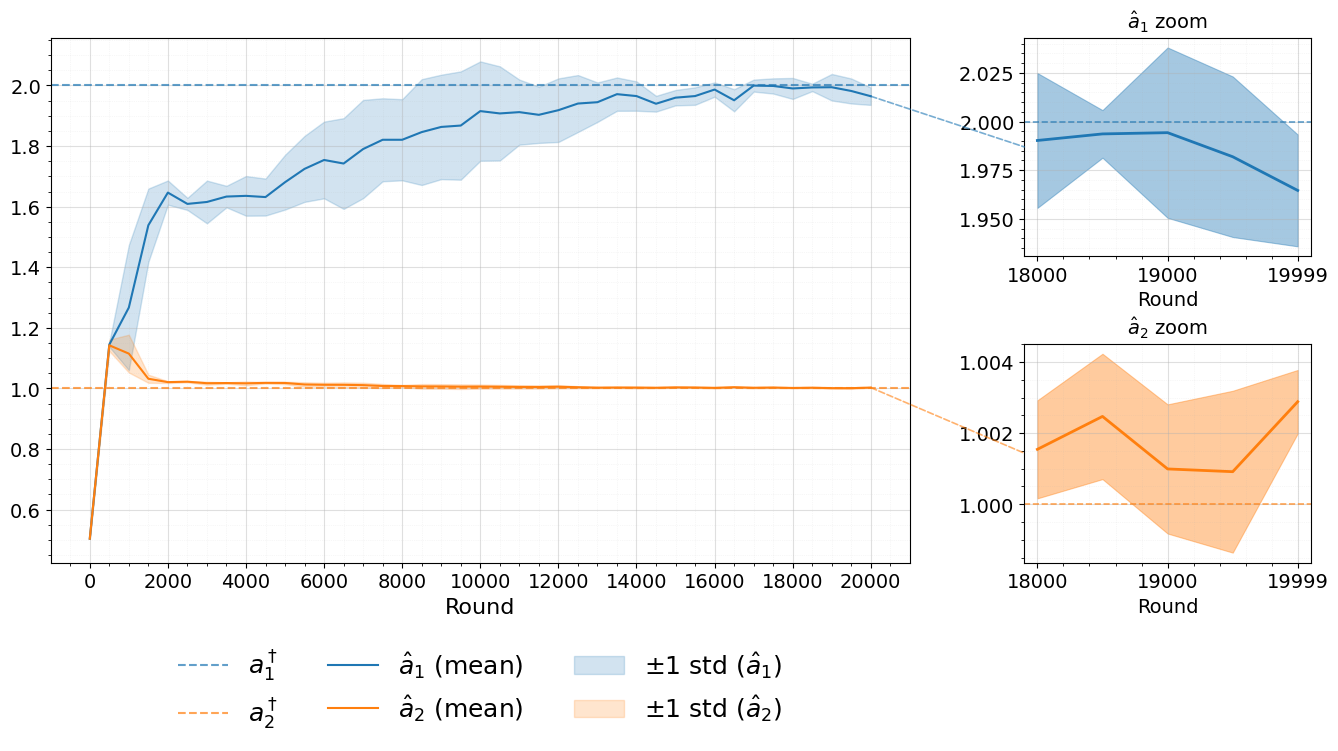

In [8]:
# =====================================================================
# Plotting Cell 2: Mean convergence with two external zoom subplots
# Dashed lines from last data points to the left edge center of zoom axes
# =====================================================================

import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import ConnectionPatch

# ---------------------------------------------------------------------
# Load all standard HYCO result files (no weight suffix)
# ---------------------------------------------------------------------
all_files = glob.glob(os.path.join(SAVE_DIR, "hyco_noise_*.pkl"))
standard_files = [f for f in all_files if "_wphy_" not in f]

a1_seqs, a2_seqs, rounds_list = [], [], []
noise_levels_found = []

for filepath in standard_files:
    basename = os.path.basename(filepath)
    try:
        # Extract noise level from filename (e.g., hyco_noise_0.05.pkl -> 0.05)
        noise_str = basename.split('_')[2].replace('.pkl', '')
        nl = float(noise_str)
    except:
        continue
    try:
        res = load_result('hyco', nl)
        hist = res.history
        r = np.array(hist["round"])
        a1 = np.array(hist["a1"])
        a2 = np.array(hist["a2"])
        if len(r) == 0:
            continue
        noise_levels_found.append(nl)
        a1_seqs.append(a1)
        a2_seqs.append(a2)
        rounds_list.append(r)
        print(f"Loaded noise {nl:.2f}: {len(r)} recorded rounds.")
    except Exception as e:
        print(f"Error loading noise {nl:.2f}: {e}")

if len(a1_seqs) == 0:
    raise RuntimeError("No HYCO histories found.")

# ---------------------------------------------------------------------
# Truncate all sequences to the shortest common length
# ---------------------------------------------------------------------
common_rounds = rounds_list[0]
min_len = min(len(r) for r in rounds_list)
if any(len(r) != min_len for r in rounds_list):
    print("Truncating all sequences to shortest length.")
    common_rounds = common_rounds[:min_len]
    a1_seqs = [seq[:min_len] for seq in a1_seqs]
    a2_seqs = [seq[:min_len] for seq in a2_seqs]

a1_arr = np.array(a1_seqs)
a2_arr = np.array(a2_seqs)

# ---------------------------------------------------------------------
# Compute mean and standard deviation across noise levels
# ---------------------------------------------------------------------
a1_mean = np.mean(a1_arr, axis=0)
a2_mean = np.mean(a2_arr, axis=0)
# show_fill: whether to display the ±1 std shaded region (requires at least 2 noise levels)
if a1_arr.shape[0] >= 2:
    a1_std = np.std(a1_arr, axis=0, ddof=1)
    a2_std = np.std(a2_arr, axis=0, ddof=1)
    show_fill = True
else:
    a1_std = np.zeros_like(a1_mean)
    a2_std = np.zeros_like(a2_mean)
    show_fill = False

# ---------------------------------------------------------------------
# Zoom interval: take the last N_ZOOM recorded points
# N_ZOOM = number of points in the zoomed region (adjustable)
# ---------------------------------------------------------------------
N_ZOOM = 5
zoom_start = max(0, min_len - N_ZOOM)
zoom_end = min_len
zoom_rounds = common_rounds[zoom_start:zoom_end]
x1, x2 = zoom_rounds[0], zoom_rounds[-1]   # x1: left bound, x2: right bound of zoom

# ---------------------------------------------------------------------
# Create figure with GridSpec layout
# ---------------------------------------------------------------------
# figsize: overall figure size (width, height) in inches
fig = plt.figure(figsize=(15, 7))

# GridSpec:
# - 2 rows, 2 columns (left column for main plot, right column for two zoom axes)
# - width_ratios: [left_width, right_width] (right column is narrower)
# - height_ratios: [top_row_height, bottom_row_height] (both equal)
# - wspace: horizontal spacing between left and right columns (larger = more space)
# - hspace: vertical spacing between the two zoom axes (larger = more space)
gs = GridSpec(2, 2, width_ratios=[3, 1], height_ratios=[0.8, 0.8],
              wspace=0.2, hspace=0.4)   # adjust these to control gaps

# Main plot occupies both rows in the left column
ax = fig.add_subplot(gs[:, 0])

# ---------------------------------------------------------------------
# Plot main curves (a1 mean, a2 mean, true values)
# ---------------------------------------------------------------------
ax.plot(common_rounds, a1_mean, color='C0', label=r'$\hat{a}_1$ (mean)')
if show_fill:
    ax.fill_between(common_rounds, a1_mean - a1_std, a1_mean + a1_std,
                    color='C0', alpha=0.2, label=r'$\pm 1$ std ($\hat{a}_1$)')
ax.plot(common_rounds, a2_mean, color='C1', label=r'$\hat{a}_2$ (mean)')
if show_fill:
    ax.fill_between(common_rounds, a2_mean - a2_std, a2_mean + a2_std,
                    color='C1', alpha=0.2, label=r'$\pm 1$ std ($\hat{a}_2$)')

ax.axhline(A_TRUE[0], color='C0', linestyle='--', alpha=0.7, label=r'$a_1^\dagger$')
ax.axhline(A_TRUE[1], color='C1', linestyle='--', alpha=0.7, label=r'$a_2^\dagger$')

# ---------------------------------------------------------------------
# Grid and ticks for main plot
# ---------------------------------------------------------------------
# Set major x-ticks every 2000 rounds, minor every 500
ax.grid(True, which='major', alpha=0.4, linestyle='-', linewidth=0.8)
ax.grid(True, which='minor', alpha=0.2, linestyle=':', linewidth=0.5)
ax.minorticks_on()
ax.xaxis.set_major_locator(MultipleLocator(2000))
ax.xaxis.set_minor_locator(MultipleLocator(500))
ax.set_xlabel('Round', fontsize=16)
ax.tick_params(labelsize=14)

# ---------------------------------------------------------------------
# Legend: reorder handles so that true values appear first, then means, then std
# ---------------------------------------------------------------------
handles, labels = ax.get_legend_handles_labels()
if show_fill:
    order = [4, 5, 0, 2, 1, 3]   # true, mean, std
else:
    order = [2, 3, 0, 1]
handles_ordered = [handles[i] for i in order]
labels_ordered = [labels[i] for i in order]
ax.legend(handles_ordered, labels_ordered,
          loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fontsize=18, ncol=3, frameon=False)

# ---------------------------------------------------------------------
# Extract zoomed data (mean and std for the zoom interval)
# ---------------------------------------------------------------------
a1_mean_zoom = a1_mean[zoom_start:zoom_end]
a1_std_zoom  = a1_std[zoom_start:zoom_end] if show_fill else np.zeros_like(a1_mean_zoom)
a2_mean_zoom = a2_mean[zoom_start:zoom_end]
a2_std_zoom  = a2_std[zoom_start:zoom_end] if show_fill else np.zeros_like(a2_mean_zoom)

# ---------------------------------------------------------------------
# Top-right: zoom for a1
# ---------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 1])
ax1.fill_between(zoom_rounds, a1_mean_zoom - a1_std_zoom, a1_mean_zoom + a1_std_zoom,
                 color='C0', alpha=0.4, edgecolor='C0', linewidth=0.8)
ax1.plot(zoom_rounds, a1_mean_zoom, color='C0', linewidth=2)
ax1.axhline(A_TRUE[0], color='C0', linestyle='--', linewidth=1.2, alpha=0.7)
ax1.grid(True, which='major', alpha=0.4, linestyle='-', linewidth=0.8)
ax1.grid(True, which='minor', alpha=0.2, linestyle=':', linewidth=0.5)
ax1.minorticks_on()
# x-ticks: only show left bound, 19000, and right bound (to avoid overcrowding)
ax1.set_xticks([x1, 19000, x2])
ax1.tick_params(labelsize=14)
ax1.set_xlabel('Round', fontsize=14)
ax1.set_title(r'$\hat{a}_1$ zoom', fontsize=14)

# ---------------------------------------------------------------------
# Bottom-right: zoom for a2
# ---------------------------------------------------------------------
ax2 = fig.add_subplot(gs[1, 1])
ax2.fill_between(zoom_rounds, a2_mean_zoom - a2_std_zoom, a2_mean_zoom + a2_std_zoom,
                 color='C1', alpha=0.4, edgecolor='C1', linewidth=0.8)
ax2.plot(zoom_rounds, a2_mean_zoom, color='C1', linewidth=2)
ax2.axhline(A_TRUE[1], color='C1', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.grid(True, which='major', alpha=0.4, linestyle='-', linewidth=0.8)
ax2.grid(True, which='minor', alpha=0.2, linestyle=':', linewidth=0.5)
ax2.minorticks_on()
ax2.set_xticks([x1, 19000, x2])
ax2.tick_params(labelsize=14)
ax2.set_xlabel('Round', fontsize=14)
ax2.set_title(r'$\hat{a}_2$ zoom', fontsize=14)

# ---------------------------------------------------------------------
# Connecting dashed lines from the last data point on main plot
# to the left edge center of each zoom axis
# ---------------------------------------------------------------------
x_last = common_rounds[-1]   # e.g., 20000
y_start_a1 = a1_mean[-1]
y_start_a2 = a2_mean[-1]

# End point in axes fraction: (0, 0.5) means left edge, vertical center
end_point = (0, 0.5)

# ConnectionPatch parameters:
# - xyA: start point in data coordinates of axesA
# - xyB: end point in axes fraction coordinates of axesB
# - coordsA='data', coordsB='axes fraction' specify coordinate systems
# - axesA, axesB: the parent axes
# - color, linestyle, linewidth, alpha: style of the connecting line
con1 = ConnectionPatch(xyA=(x_last, y_start_a1), xyB=end_point,
                       coordsA='data', coordsB='axes fraction',
                       axesA=ax, axesB=ax1,
                       color='C0', linestyle='--', linewidth=1.2, alpha=0.6)

con2 = ConnectionPatch(xyA=(x_last, y_start_a2), xyB=end_point,
                       coordsA='data', coordsB='axes fraction',
                       axesA=ax, axesB=ax2,
                       color='C1', linestyle='--', linewidth=1.2, alpha=0.6)

fig.add_artist(con1)
fig.add_artist(con2)

# ---------------------------------------------------------------------
# Adjust subplot spacing and save
# ---------------------------------------------------------------------
# subplots_adjust: fine-tune margins (bottom, left, right, top)
plt.subplots_adjust(bottom=0.2, left=0.08, right=0.92, top=0.95)

save_path_pdf = os.path.join(SAVE_DIR, "Ex1_param_convergence_multi_noise_mean_std.pdf")
save_path_png = os.path.join(SAVE_DIR, "Ex1_param_convergence_multi_noise_mean_std.png")
plt.savefig(save_path_pdf, dpi=300, bbox_inches='tight')
plt.savefig(save_path_png, dpi=600, bbox_inches='tight')
print(f"Saved multi-noise convergence figure to {save_path_pdf}")

plt.show()

8. Generate the Table in the paper

In [4]:
# ============================================================
# Cell 13: Generate LaTeX tables (Fully dynamic columns)
# ============================================================

import os
import pickle
import numpy as np

# ---------- Define classes for unpickling ----------
class HYCOResult: pass
class PINNResult: pass
class XPINNResult: pass
class PINNModel: pass
class XPINNModel: pass
class MLP: pass

# ---------- Loading functions ----------
def load_result(method, noise_level):
    filename = os.path.join(SAVE_DIR, f"{method}_noise_{noise_level:.2f}.pkl")
    with open(filename, 'rb') as f:
        return pickle.load(f)

def load_weight_result(noise_level, weight):
    filename = os.path.join(SAVE_DIR, f"hyco_noise_{noise_level:.2f}_wphy_{weight:.2f}.pkl")
    with open(filename, 'rb') as f:
        return pickle.load(f)


NOISE_LEVELS = [0.00, 0.05, 0.10, 0.15, 0.20]   

# ---------- Load all HYCO results ----------
all_res = {}
for noise in NOISE_LEVELS:
    try:
        all_res[noise] = load_result('hyco', noise)
        print(f"Loaded η={noise:.2f}")
    except FileNotFoundError:
        print(f"Warning: η={noise:.2f} not found.")

if not all_res:
    raise RuntimeError("No HYCO results. Run Cell 7 first.")

# Prepare rows for Tables 1–3
rows = []
for noise, r in sorted(all_res.items()):
    rows.append({
        'noise': noise,
        'a1': r.a[0], 'a2': r.a[1],
        'delta_a1': r.delta_a1, 'delta_a2': r.delta_a2,
        'e_gamma': np.sqrt(r.delta_a1**2 + r.delta_a2**2),
        'runtime': r.runtime,
        'e_phy_Omega': r.e_phy_Omega,
        'e_syn_Omega': r.e_syn_Omega,
        'e_phy_Omega1': r.e_phy_Omega1,
        'e_phy_Omega2': r.e_phy_Omega2,
        'e_syn_Omega1': r.e_syn_Omega1,
        'e_syn_Omega2': r.e_syn_Omega2,
        'Gap_phy': r.Gap_phy,
        'Gap_syn': r.Gap_syn,
        'e_int_train': r.e_int_train,
        'e_int_test': r.e_int_test,
        'jump_u_phy': r.jump_u_phy,
        'jump_u_syn': r.jump_u_syn,
        'jump_flux_phy': r.jump_flux_phy,
        'jump_flux_syn': r.jump_flux_syn,
    })

# Load PINN & XPINN (η=0.00)
hyco_0 = load_result('hyco', 0.00)
pinn_0 = load_result('pinn', 0.00)
xpinn_0 = load_result('xpinn', 0.00)

# ---------- Helper: compute interface jumps ----------
def compute_jumps(u_pred, a1, a2, points, eps_if=1e-4, n_if=500):
    X_if, N_if = interface_points_and_normals_np(n_if)
    X_if_minus = X_if - eps_if * N_if
    X_if_plus  = X_if + eps_if * N_if
    interp = make_interpolator(points, u_pred)
    u_minus = interp(X_if_minus)
    u_plus  = interp(X_if_plus)
    du_dn = (u_plus - u_minus) / (2.0 * eps_if)
    flux_inner = a1 * du_dn
    flux_outer = a2 * du_dn
    jump_u = np.sqrt(np.mean((u_plus - u_minus)**2))
    jump_flux = np.sqrt(np.mean((flux_outer - flux_inner)**2))
    return jump_u, jump_flux

# ---------- Compute comparison metrics ----------
# HYCO
hyco_a1, hyco_a2 = hyco_0.a
hyco_da1, hyco_da2 = hyco_0.delta_a1, hyco_0.delta_a2
hyco_eg = hyco_0.e_gamma
hyco_e_phy_Omega = hyco_0.e_phy_Omega
hyco_e_syn_Omega = hyco_0.e_syn_Omega
hyco_e_phy_Omega1 = hyco_0.e_phy_Omega1
hyco_e_syn_Omega1 = hyco_0.e_syn_Omega1
hyco_e_phy_Omega2 = hyco_0.e_phy_Omega2
hyco_e_syn_Omega2 = hyco_0.e_syn_Omega2
hyco_Gap_phy = hyco_0.Gap_phy
hyco_Gap_syn = hyco_0.Gap_syn
hyco_jump_u_phy = hyco_0.jump_u_phy
hyco_jump_u_syn = hyco_0.jump_u_syn
hyco_jump_flux_phy = hyco_0.jump_flux_phy
hyco_jump_flux_syn = hyco_0.jump_flux_syn
hyco_time = hyco_0.runtime

# PINN
pinn_a1, pinn_a2 = pinn_0.a
pinn_da1 = abs(pinn_a1 - A_TRUE[0]) / A_TRUE[0]
pinn_da2 = abs(pinn_a2 - A_TRUE[1]) / A_TRUE[1]
pinn_eg = np.sqrt(pinn_da1**2 + pinn_da2**2)
pinn_u = pinn_0.u
pinn_e_full = relative_l2_error_on_mesh(pinn_u, u_true, lumped_mass)
mask_inner = inside_inner_np(points)
mask_outer = ~mask_inner
mass_inner = lumped_mass[mask_inner]
mass_outer = lumped_mass[mask_outer]
pinn_e_Omega1 = relative_l2_error_on_mesh(pinn_u[mask_inner], u_true[mask_inner], mass_inner)
pinn_e_Omega2 = relative_l2_error_on_mesh(pinn_u[mask_outer], u_true[mask_outer], mass_outer)
pinn_Gap = pinn_e_Omega2 - pinn_e_Omega1
pinn_jump_u, pinn_jump_flux = compute_jumps(pinn_u, pinn_a1, pinn_a2, points)
pinn_time = pinn_0.runtime

# XPINN
xpinn_a1, xpinn_a2 = xpinn_0.a
xpinn_da1 = abs(xpinn_a1 - A_TRUE[0]) / A_TRUE[0]
xpinn_da2 = abs(xpinn_a2 - A_TRUE[1]) / A_TRUE[1]
xpinn_eg = np.sqrt(xpinn_da1**2 + xpinn_da2**2)
xpinn_u = xpinn_0.u
xpinn_e_full = relative_l2_error_on_mesh(xpinn_u, u_true, lumped_mass)
xpinn_e_Omega1 = relative_l2_error_on_mesh(xpinn_u[mask_inner], u_true[mask_inner], mass_inner)
xpinn_e_Omega2 = relative_l2_error_on_mesh(xpinn_u[mask_outer], u_true[mask_outer], mass_outer)
xpinn_Gap = xpinn_e_Omega2 - xpinn_e_Omega1
xpinn_jump_u, xpinn_jump_flux = compute_jumps(xpinn_u, xpinn_a1, xpinn_a2, points)
xpinn_time = xpinn_0.runtime

# ------------------------------------------------------------
# Helper: dynamic table header
# ------------------------------------------------------------
def build_dynamic_header(n_noise):
    col_format = "l" + "c" * n_noise
    if n_noise == 1:
        header_line = r"Metric & \(\eta\) \\"
        cmidrule = ""
    else:
        header_line = r"\multirow{2}{*}{Metric} & \multicolumn{" + str(n_noise) + r"}{c}{\(\eta\)} \\"
        cmidrule = r"\cmidrule{2-" + str(n_noise+1) + "}"
    return col_format, header_line, cmidrule

# ------------------------------------------------------------
# Table 1: Parameter estimation
# ------------------------------------------------------------
def print_table1(rows):
    n_noise = len(rows)
    col_fmt, header, cmidrule = build_dynamic_header(n_noise)
    print("\n% Table 1: Parameter estimation")
    print(r"\begin{table}[htbp]")
    print(r"\centering")
    print(r"\begin{tabular}{" + col_fmt + "}")
    print(r"\toprule")
    print(header)
    if cmidrule:
        print(cmidrule)
    noise_str = " & ".join([f"{r['noise']:.2f}" for r in rows])
    print(f" & {noise_str} \\\\")
    print(r"\midrule")
    for label, key in [(r"$\hat a_1$", "a1"), (r"$\hat a_2$", "a2"),
                       (r"$\delta a_1$", "delta_a1"), (r"$\delta a_2$", "delta_a2"),
                       (r"$e_{\gamma}$", "e_gamma"), ("Run time (s)", "runtime")]:
        vals = [f"{r[key]:.4f}" for r in rows]
        print(f"{label} & " + " & ".join(vals) + " \\\\")
    print(r"\bottomrule")
    print(r"\end{tabular}")
    print(r"\caption{Estimated diffusion coefficients and relative errors under increasing observation noise. The true vector is $\mathbf{\gamma}^\dagger = (2.0,\,1.0)^\top$ and the estimated vector is $\hat{\mathbf{\gamma}} = (\hat a_1, \hat a_2)^\top$. Relative errors are $\delta a_i = \dfrac{|\hat a_i - a_i^\dagger|}{a_i^\dagger},\ i=1,2$ and the joint error is $e_{\gamma} = \dfrac{\|\hat{\gamma} - \gamma^\dagger\|_2}{\|\gamma^\dagger\|_2}$}")
    print(r"\label{tab:elliptic-params}")
    print(r"\end{table}")

# ------------------------------------------------------------
# Table 2: Solution errors and gaps
# ------------------------------------------------------------
def print_table2(rows):
    n_noise = len(rows)
    col_fmt, header, cmidrule = build_dynamic_header(n_noise)
    print("\n% Table 2: Solution errors and gaps")
    print(r"\begin{table}[htbp]")
    print(r"\centering")
    print(r"\begin{tabular}{" + col_fmt + "}")
    print(r"\toprule")
    print(header)
    if cmidrule:
        print(cmidrule)
    noise_str = " & ".join([f"{r['noise']:.2f}" for r in rows])
    print(f" & {noise_str} \\\\")
    print(r"\midrule")
    for label, key in [(r"$e_{\rm phy}(\Omega)$", "e_phy_Omega"),
                       (r"$e_{\rm syn}(\Omega)$", "e_syn_Omega"),
                       (r"$e_{\rm phy}(\Omega_1)$", "e_phy_Omega1"),
                       (r"$e_{\rm phy}(\Omega_2)$", "e_phy_Omega2"),
                       (r"$e_{\rm syn}(\Omega_1)$", "e_syn_Omega1"),
                       (r"$e_{\rm syn}(\Omega_2)$", "e_syn_Omega2"),
                       (r"$\mathrm{Gap}_{\rm phy}$", "Gap_phy"),
                       (r"$\mathrm{Gap}_{\rm syn}$", "Gap_syn"),
                       (r"$e_{\rm int}^{\rm train}$", "e_int_train"),
                       (r"$e_{\rm int}^{\rm test}$", "e_int_test")]:
        vals = [r[key] for r in rows]
        if key in ['e_int_train', 'e_int_test']:
            vals = [f"{v:.2e}" for v in vals]
        else:
            vals = [f"{v:.4f}" for v in vals]
        print(f"{label} & " + " & ".join(vals) + " \\\\")
    print(r"\bottomrule")
    print(r"\end{tabular}")
    print(r"\caption{Relative $L^2$ errors and generalization gaps across noise levels. The relative error of a reconstructed solution $u$ with respect to the true solution $u^\dagger$ on a subdomain $\omega$ is $e_u(\omega) = \dfrac{\|u - u^\dagger\|_{L^2(\omega)}}{\|u^\dagger\|_{L^2(\omega)}}$. The generalization gaps are $\mathrm{Gap}_{\rm phy} = e_{\rm phy}(\Omega_2) - e_{\rm phy}(\Omega_1)$ and $\mathrm{Gap}_{\rm syn} = e_{\rm syn}(\Omega_1) - e_{\rm syn}(\Omega_2)$. $e_{\rm int}^{\rm train}$ and $e_{\rm int}^{\rm test}$ denote the root-mean-square difference between the physics and synthetic solutions on the training ghost points and on an independent test set of 1000 ghost points, respectively.}")
    print(r"\label{tab:elliptic-solution-errors}")
    print(r"\end{table}")

# ------------------------------------------------------------
# Table 3: Interface continuity
# ------------------------------------------------------------
def print_table3(rows):
    n_noise = len(rows)
    col_fmt, header, cmidrule = build_dynamic_header(n_noise)
    print("\n% Table 3: Interface continuity")
    print(r"\begin{table}[htbp]")
    print(r"\centering")
    print(r"\begin{tabular}{" + col_fmt + "}")
    print(r"\toprule")
    print(header)
    if cmidrule:
        print(cmidrule)
    noise_str = " & ".join([f"{r['noise']:.2f}" for r in rows])
    print(f" & {noise_str} \\\\")
    print(r"\midrule")
    for label, key in [(r"$[u]_{\rm syn}$", "jump_u_syn"),
                       (r"$[u]_{\rm phy}$", "jump_u_phy"),
                       (r"$[a\nabla u\cdot n]_{\rm phy}$", "jump_flux_phy"),
                       (r"$[a\nabla u\cdot n]_{\rm syn}$", "jump_flux_syn")]:
        vals = [f"{r[key]:.2e}" for r in rows]
        print(f"{label} & " + " & ".join(vals) + " \\\\")
    print(r"\bottomrule")
    print(r"\end{tabular}")
    print(r"\caption{Interface continuity. The interface jumps are the $L^2$ norms of the solution jump $[u]$ and the flux jump $[a\nabla u\cdot n]$ across the interface $\Gamma$ for each model.}")
    print(r"\label{tab:elliptic-interface}")
    print(r"\end{table}")

# ------------------------------------------------------------
# Table 4: Comparison (fixed 3 columns, no change)
# ------------------------------------------------------------
def print_comparison_table():
    print("\n% Table 4: Comparison between HYCO, PINN and XPINN at η=0.00")
    print(r"\begin{table}[htbp]")
    print(r"\centering")
    print(r"\setlength{\tabcolsep}{10pt}")
    print(r"\caption{Performance comparison between HYCO, PINN and XPINN at noise level $\eta=0.00$}")
    print(r"\label{tab:hyco_pinn_compare}")
    print(r"\begin{tabular}{lccc}")
    print(r"\toprule")
    print(r"\multirow{2}{*}{Metric} & \multicolumn{3}{c}{Method} \\")
    print(r"\cmidrule{2-4}")
    print(r"                        & HYCO & PINN & XPINN \\")
    print(r"\midrule")
    
    print(f"$\\hat a_1$ & {hyco_a1:.4f} & {pinn_a1:.4f} & {xpinn_a1:.4f} \\\\")
    print(f"$\\hat a_2$ & {hyco_a2:.4f} & {pinn_a2:.4f} & {xpinn_a2:.4f} \\\\")
    print(f"$\\delta a_1$ & {hyco_da1:.4f} & {pinn_da1:.4f} & {xpinn_da1:.4f} \\\\")
    print(f"$\\delta a_2$ & {hyco_da2:.4f} & {pinn_da2:.4f} & {xpinn_da2:.4f} \\\\")
    print(f"$e_\\gamma$ & {hyco_eg:.4f} & {pinn_eg:.4f} & {xpinn_eg:.4f} \\\\")
    print(r"\midrule")
    
    print(f"$e_{{\\mathrm{{phy}}}}(\\Omega)$ & {hyco_e_phy_Omega:.4f} & \\multirow{{2}}{{*}}{{{pinn_e_full:.4f}}} & \\multirow{{2}}{{*}}{{{xpinn_e_full:.4f}}} \\\\")
    print(f"$e_{{\\mathrm{{syn}}}}(\\Omega)$ & {hyco_e_syn_Omega:.4f} & & \\\\")
    
    print(f"$e_{{\\mathrm{{phy}}}}(\\Omega_1)$ & {hyco_e_phy_Omega1:.4f} & \\multirow{{2}}{{*}}{{{pinn_e_Omega1:.4f}}} & \\multirow{{2}}{{*}}{{{xpinn_e_Omega1:.4f}}} \\\\")
    print(f"$e_{{\\mathrm{{syn}}}}(\\Omega_1)$ & {hyco_e_syn_Omega1:.4f} & & \\\\")
    
    print(f"$e_{{\\mathrm{{phy}}}}(\\Omega_2)$ & {hyco_e_phy_Omega2:.4f} & \\multirow{{2}}{{*}}{{{pinn_e_Omega2:.4f}}} & \\multirow{{2}}{{*}}{{{xpinn_e_Omega2:.4f}}} \\\\")
    print(f"$e_{{\\mathrm{{syn}}}}(\\Omega_2)$ & {hyco_e_syn_Omega2:.4f} & & \\\\")
    
    print(f"$\\mathrm{{Gap}}_{{\\mathrm{{phy}}}}$ & {hyco_Gap_phy:.4f} & \\multirow{{2}}{{*}}{{{pinn_Gap:.4f}}} & \\multirow{{2}}{{*}}{{{xpinn_Gap:.4f}}} \\\\")
    print(f"$\\mathrm{{Gap}}_{{\\mathrm{{syn}}}}$ & {hyco_Gap_syn:.4f} & & \\\\")
    
    print(r"\midrule")
    
    print(f"$[u]_{{\\mathrm{{phy}}}}$ & {hyco_jump_u_phy:.5f} & \\multirow{{2}}{{*}}{{{pinn_jump_u:.5f}}} & \\multirow{{2}}{{*}}{{{xpinn_jump_u:.5f}}} \\\\")
    print(f"$[u]_{{\\mathrm{{syn}}}}$ & {hyco_jump_u_syn:.5f} & & \\\\")
    
    print(f"$[a\\nabla u\\cdot n]_{{\\mathrm{{phy}}}}$ & {hyco_jump_flux_phy:.4f} & \\multirow{{2}}{{*}}{{{pinn_jump_flux:.4f}}} & \\multirow{{2}}{{*}}{{{xpinn_jump_flux:.4f}}} \\\\")
    print(f"$[a\\nabla u\\cdot n]_{{\\mathrm{{syn}}}}$ & {hyco_jump_flux_syn:.4f} & & \\\\")
    
    print(r"\midrule")
    
    print(f"Run time (s) & {hyco_time:.1f} & {pinn_time:.1f} & {xpinn_time:.1f} \\\\")
    print(r"\bottomrule")
    print(r"\end{tabular}")
    print(r"\end{table}")

# ------------------------------------------------------------
# Table 5: Weight sensitivity (fixed 6 columns)
# ------------------------------------------------------------
def print_weight_sensitivity_table():
    weight_list = [1.0, 0.75, 0.5, 0.25, 0.0]
    noise_level = 0.20
    data = []
    for w in weight_list:
        try:
            res = load_weight_result(noise_level, w)
            a1, a2 = res.a
            da1 = abs(a1 - A_TRUE[0]) / A_TRUE[0]
            da2 = abs(a2 - A_TRUE[1]) / A_TRUE[1]
            eg = np.linalg.norm(res.a - A_TRUE) / np.linalg.norm(A_TRUE)
            data.append((w, a1, a2, da1, da2, eg))
        except FileNotFoundError:
            print(f"Warning: weight {w} not found.")
    if not data:
        print("No weight sensitivity data.")
        return
    print("\n% Table 5: Weight sensitivity analysis for HYCO at η=0.20")
    print(r"\begin{table}[htbp]")
    print(r"\centering")
    print(r"\caption{Performance metrics for different aggregation weights at noise level $\eta=0.20$}")
    print(r"\label{tab:weight_sensitivity}")
    print(r"\begin{tabular}{lccccc}")
    print(r"\toprule")
    print(r"$(w_{\mathrm{phy}}, w_{\mathrm{syn}})$ & $\hat a_1$ & $\hat a_2$ & $\delta a_1$ & $\delta a_2$ & $e_\gamma$ \\")
    print(r"\midrule")
    for w, a1, a2, da1, da2, eg in data:
        label = f"({w:.2f}, {1-w:.2f})"
        print(f"{label} & {a1:.4f} & {a2:.4f} & {da1:.4f} & {da2:.4f} & {eg:.4f} \\\\")
    print(r"\bottomrule")
    print(r"\end{tabular}")
    print(r"\end{table}")

# ---------- Generate all tables ----------
print_table1(rows)
print_table2(rows)
print_table3(rows)
print_comparison_table()
print_weight_sensitivity_table()

print("\nAll LaTeX tables generated.")

Loaded η=0.00
Loaded η=0.05
Loaded η=0.10
Loaded η=0.15
Loaded η=0.20

% Table 1: Parameter estimation
\begin{table}[htbp]
\centering
\begin{tabular}{lccccc}
\toprule
\multirow{2}{*}{Metric} & \multicolumn{5}{c}{\(\eta\)} \\
\cmidrule{2-6}
 & 0.00 & 0.05 & 0.10 & 0.15 & 0.20 \\
\midrule
$\hat a_1$ & 1.9394 & 2.0013 & 1.9388 & 1.9786 & 1.9899 \\
$\hat a_2$ & 1.0029 & 1.0035 & 1.0040 & 1.0014 & 1.0026 \\
$\delta a_1$ & 0.0303 & 0.0007 & 0.0306 & 0.0107 & 0.0050 \\
$\delta a_2$ & 0.0029 & 0.0035 & 0.0040 & 0.0014 & 0.0026 \\
$e_{\gamma}$ & 0.0304 & 0.0036 & 0.0309 & 0.0108 & 0.0057 \\
Run time (s) & 2581.9311 & 2585.3934 & 2569.6963 & 2638.7329 & 2625.0078 \\
\bottomrule
\end{tabular}
\caption{Estimated diffusion coefficients and relative errors under increasing observation noise. The true vector is $\mathbf{\gamma}^\dagger = (2.0,\,1.0)^\top$ and the estimated vector is $\hat{\mathbf{\gamma}} = (\hat a_1, \hat a_2)^\top$. Relative errors are $\delta a_i = \dfrac{|\hat a_i - a_i^\dagger|}

9. Plot the Solution and Gradient Pictures

HYCO loaded.
PINN loaded.
XPINN loaded.


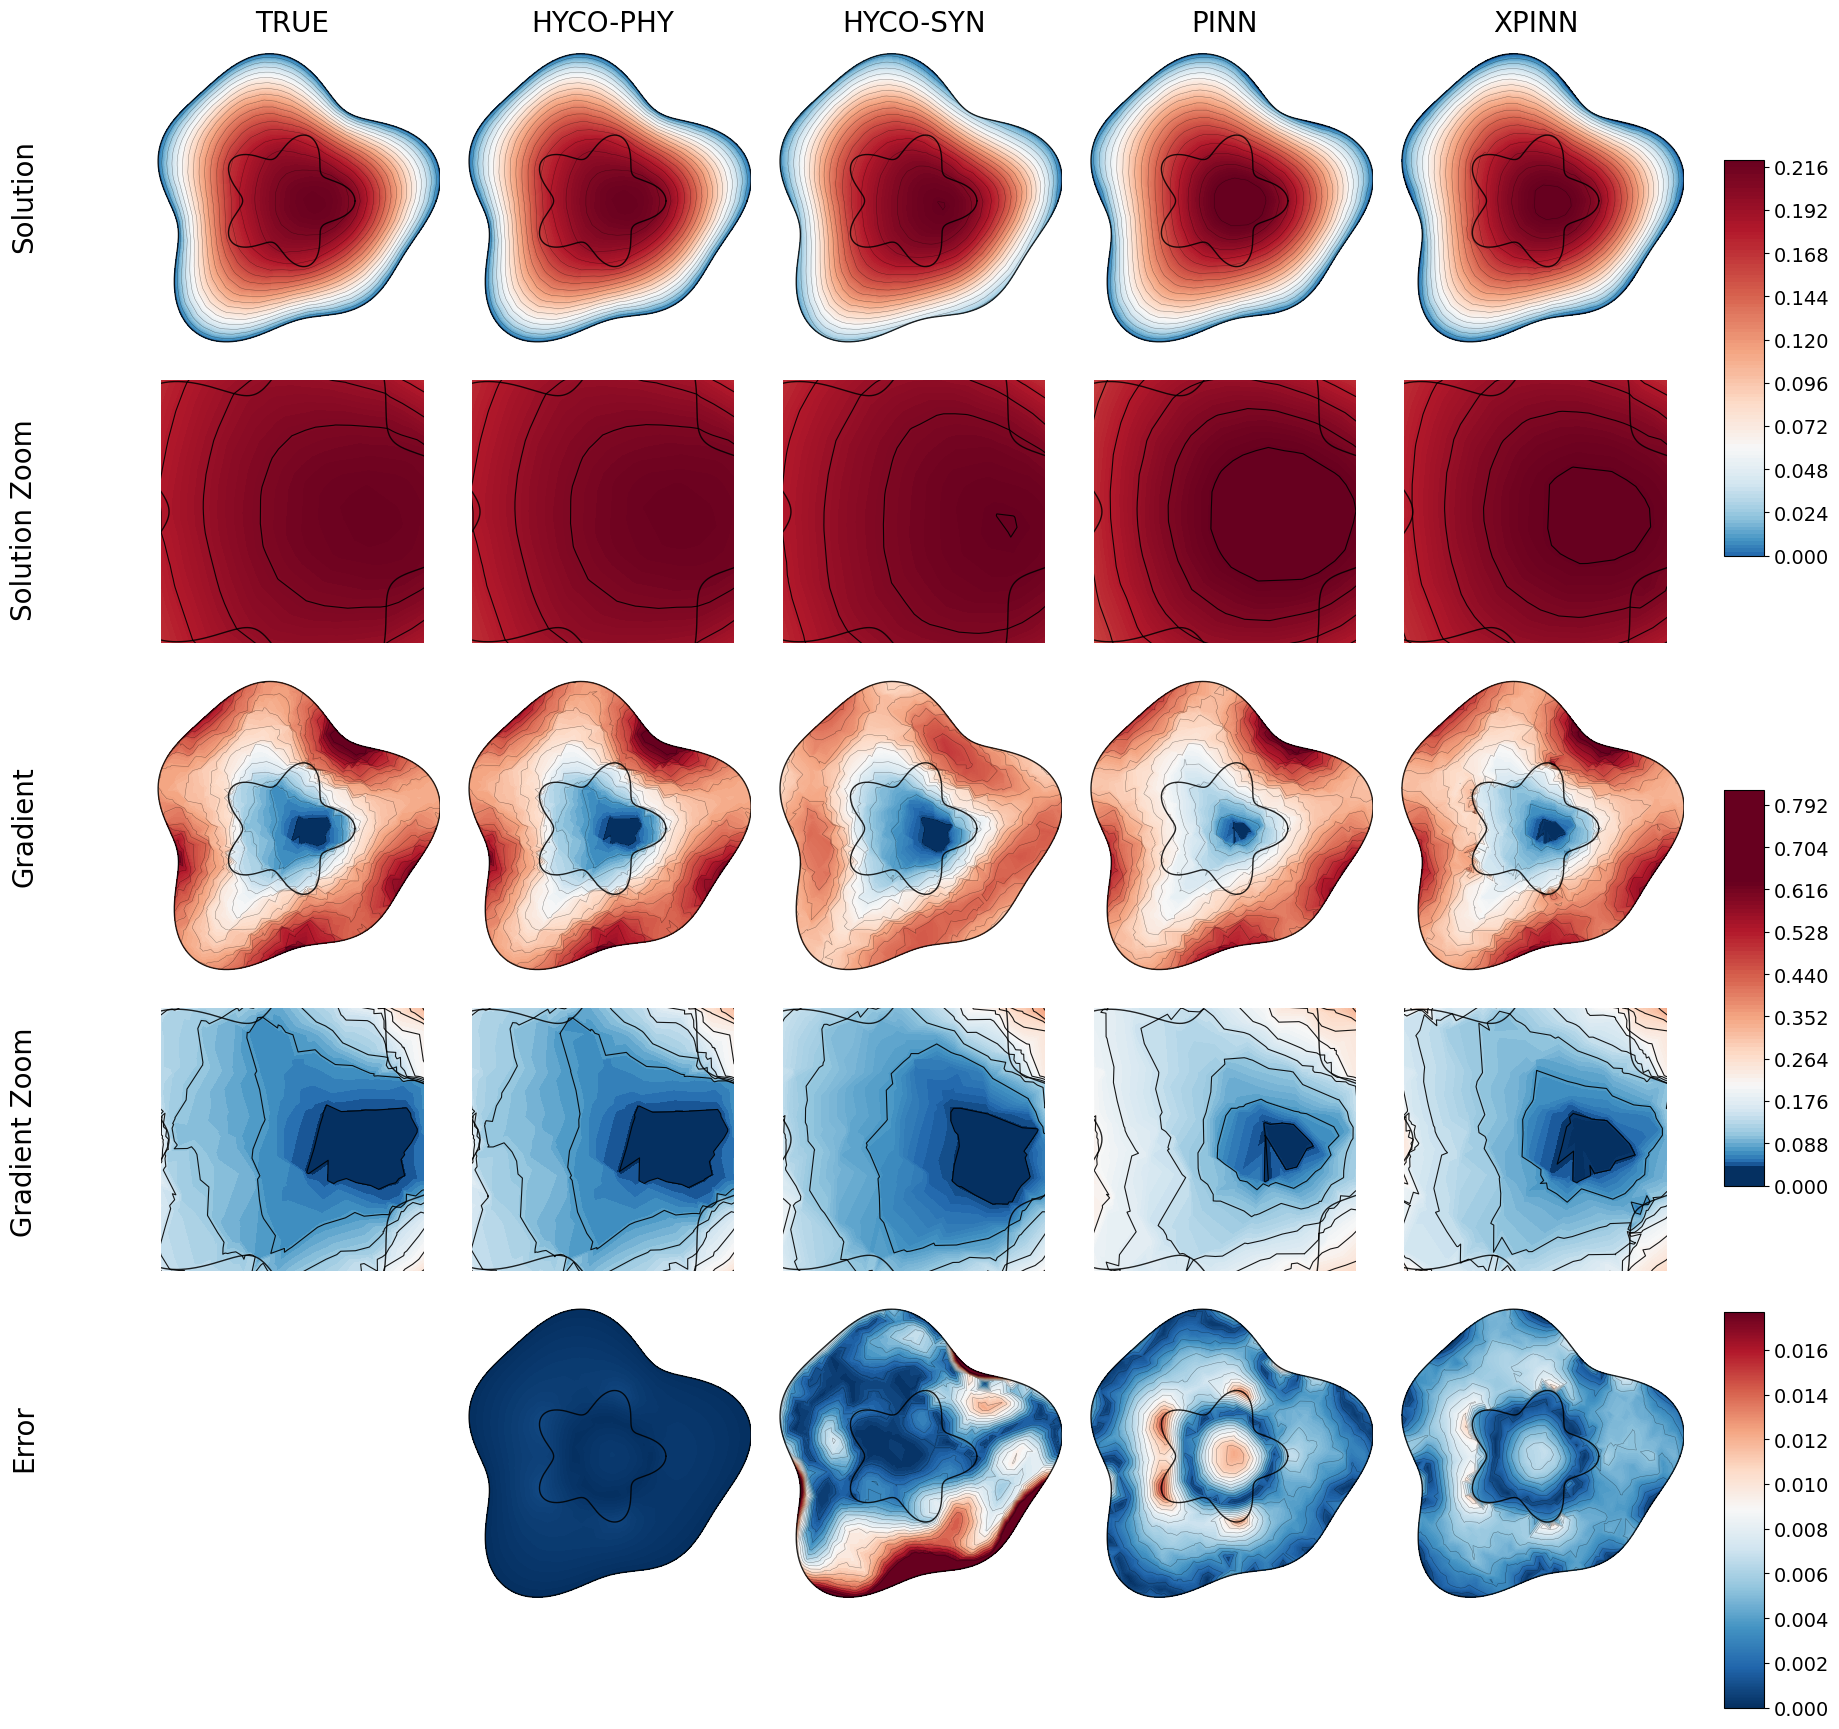

Figure saved as Ex1_combined_5x5_error_cell4style_noise_0.00.png and .pdf in ./results_elliptic2/


In [10]:
# =====================================================================
# Plotting Cell 3f: Full 5×5 layout (Error row exactly like Cell 4)
# Row 0: Global solutions
# Row 1: Local zoom of solutions
# Row 2: Global gradient magnitudes
# Row 3: Local zoom of gradient magnitudes
# Row 4: Absolute errors (linear norm, vmin=0, vmax=98% percentile)
# =====================================================================
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.colors import PowerNorm
import numpy as np
import matplotlib.pyplot as plt

NOISE_TO_PLOT = 0.00

# ------------------------------------------------------------
# Load results
# ------------------------------------------------------------
try:
    hyco_res = load_result('hyco', NOISE_TO_PLOT)
    print("HYCO loaded.")
except FileNotFoundError:
    raise RuntimeError(f"HYCO result for η={NOISE_TO_PLOT:.2f} not found.")

try:
    pinn_res = load_result('pinn', 0.00)
    print("PINN loaded.")
except FileNotFoundError:
    raise RuntimeError("PINN result not found. Run Cell 8 first.")

try:
    xpinn_res = load_result('xpinn', 0.00)
    print("XPINN loaded.")
except FileNotFoundError:
    raise RuntimeError("XPINN result not found. Run Cell 9 first.")

# ------------------------------------------------------------
# Gradient magnitude function
# ------------------------------------------------------------
def gradient_magnitude_on_nodes(points, triangles, u):
    grad_x = np.zeros(len(points))
    grad_y = np.zeros(len(points))
    weights = np.zeros(len(points))
    for tri in triangles:
        p0 = points[tri[0]]
        p1 = points[tri[1]]
        p2 = points[tri[2]]
        x0, y0 = p0
        x1, y1 = p1
        x2, y2 = p2
        det = (x1-x0)*(y2-y0) - (x2-x0)*(y1-y0)
        if abs(det) < 1e-12:
            continue
        u0, u1, u2 = u[tri[0]], u[tri[1]], u[tri[2]]
        ux = ((u1-u0)*(y2-y0) - (u2-u0)*(y1-y0)) / det
        uy = ((u2-u0)*(x1-x0) - (u1-u0)*(x2-x0)) / det
        area = 0.5 * abs(det)
        for i in tri:
            grad_x[i] += ux * area
            grad_y[i] += uy * area
            weights[i] += area
    weights = np.maximum(weights, 1e-12)
    grad_x /= weights
    grad_y /= weights
    return np.sqrt(grad_x**2 + grad_y**2)

# Compute gradients
grad_true = gradient_magnitude_on_nodes(points, triangles, u_true)
grad_pinn = gradient_magnitude_on_nodes(points, triangles, pinn_res.u)
grad_hyco_phy = gradient_magnitude_on_nodes(points, triangles, hyco_res.u_phy)
grad_hyco_syn = gradient_magnitude_on_nodes(points, triangles, hyco_res.u_syn)
grad_xpinn = gradient_magnitude_on_nodes(points, triangles, xpinn_res.u)

# ------------------------------------------------------------
# Error data (absolute error vs true solution)
# ------------------------------------------------------------
err_raw = {
    "TRUE": np.zeros_like(u_true),
    "HYCO-PHY": np.abs(hyco_res.u_phy - u_true),
    "HYCO-SYN": np.abs(hyco_res.u_syn - u_true),
    "PINN": np.abs(pinn_res.u - u_true),
    "XPINN": np.abs(xpinn_res.u - u_true),
}
err_data = err_raw  # 直接使用，TRUE 为 0

# ------------------------------------------------------------
# Data dictionaries (order: TRUE, HYCO-PHY, HYCO-SYN, PINN, XPINN)
# ------------------------------------------------------------
method_order = ["TRUE", "HYCO-PHY", "HYCO-SYN", "PINN", "XPINN"]

sol_data = {
    "TRUE": u_true,
    "HYCO-PHY": hyco_res.u_phy,
    "HYCO-SYN": hyco_res.u_syn,
    "PINN": pinn_res.u,
    "XPINN": xpinn_res.u,
}
grad_data = {
    "TRUE": grad_true,
    "HYCO-PHY": grad_hyco_phy,
    "HYCO-SYN": grad_hyco_syn,
    "PINN": grad_pinn,
    "XPINN": grad_xpinn,
}

# ------------------------------------------------------------
# Color limits (global for each quantity)
# ------------------------------------------------------------
all_sol = np.concatenate([sol_data[name] for name in method_order])
all_grad = np.concatenate([grad_data[name] for name in method_order])

vmin_sol = np.percentile(all_sol, 1)
vmax_sol = np.percentile(all_sol, 99)
vmin_grad = np.percentile(all_grad, 1)
vmax_grad = np.percentile(all_grad, 99)

# --- For errors: 使用与 Cell 4 完全一致的归一化 ---
all_err_non_true = np.concatenate([err_raw[name] for name in method_order if name != "TRUE"])
vmax_err = np.percentile(all_err_non_true, 98) if np.max(all_err_non_true) > 0 else 1.0
vmin_err = 0.0

norm_sol = Normalize(vmin=vmin_sol, vmax=vmax_sol)          # 解使用线性归一化（也可保留 PowerNorm，但用户未提，我们保持与其他行一致，但为了误差行我们单独改）
# 为保持一致性，我们将解和梯度也改为线性归一化（或者保留 PowerNorm？因为用户没说要改它们，但为了与误差行一致，最好统一，但用户只要求误差行像 Cell 4，所以只改误差行）
# 这里我们保留原有的 PowerNorm 用于解和梯度，但误差行使用 Normalize
norm_sol = PowerNorm(gamma=0.55, vmin=vmin_sol, vmax=vmax_sol)
norm_grad = PowerNorm(gamma=0.55, vmin=vmin_grad, vmax=vmax_grad)
norm_err = Normalize(vmin=vmin_err, vmax=vmax_err)          # 线性归一化，与 Cell 4 一致

# Contour levels
N_LINE = 18
line_levels_sol = np.linspace(vmin_sol, vmax_sol, N_LINE)
line_levels_grad = np.linspace(vmin_grad, vmax_grad, N_LINE)
line_levels_err = np.linspace(vmin_err, vmax_err, N_LINE)    # 线性等距
N_FILL = 120

# ------------------------------------------------------------
# Local zoom region
# ------------------------------------------------------------
ZOOM_XLIM = (-0.35, 0.35)
ZOOM_YLIM = (-0.35, 0.35)

# ------------------------------------------------------------
# Create 5x5 grid with height ratios
# ------------------------------------------------------------
fig = plt.figure(figsize=(20, 18))
gs = gridspec.GridSpec(5, 5, wspace=0.05, hspace=0.06,
                       height_ratios=[1, 0.8, 1, 0.8, 1])

ax_sol_glob = [fig.add_subplot(gs[0, j]) for j in range(5)]
ax_sol_zoom = [fig.add_subplot(gs[1, j]) for j in range(5)]
ax_grad_glob = [fig.add_subplot(gs[2, j]) for j in range(5)]
ax_grad_zoom = [fig.add_subplot(gs[3, j]) for j in range(5)]
ax_err = [fig.add_subplot(gs[4, j]) for j in range(5)]

# ------------------------------------------------------------
# Plotting helpers
# ------------------------------------------------------------
def plot_global(ax, data, title, norm, line_levels, cmap="RdBu_r"):
    cf = ax.tricontourf(triangulation, data, levels=N_FILL,
                        cmap=cmap, norm=norm)
    ax.tricontour(triangulation, data, levels=line_levels,
                  colors="k", linewidths=0.32, alpha=0.45)
    overlay_boundaries(ax)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=20)
    ax.axis("off")
    return cf

def plot_zoom(ax, data, title, norm, line_levels, xlim, ylim, cmap="RdBu_r"):
    cf = ax.tricontourf(triangulation, data, levels=N_FILL,
                        cmap=cmap, norm=norm)
    ax.tricontour(triangulation, data, levels=line_levels,
                  colors="k", linewidths=0.8, alpha=0.9)
    overlay_boundaries(ax)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=16)
    ax.axis("off")
    return cf

def plot_err(ax, data, title, norm, line_levels):
    # 使用 viridis  colormap 与 Cell 4 一致，且归一化为线性
    cf = ax.tricontourf(triangulation, data, levels=N_FILL,
                        cmap="RdBu_r", norm=norm)   # 改为 viridis
    ax.tricontour(triangulation, data, levels=line_levels,
                  colors="k", linewidths=0.32, alpha=0.45)
    overlay_boundaries(ax)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=16)
    ax.axis("off")
    return cf

# ------------------------------------------------------------
# Fill all axes
# ------------------------------------------------------------
cf_sol_glob = []
for j, name in enumerate(method_order):
    cf = plot_global(ax_sol_glob[j], sol_data[name], name, norm_sol, line_levels_sol)
    cf_sol_glob.append(cf)

for j, name in enumerate(method_order):
    plot_zoom(ax_sol_zoom[j], sol_data[name], "", norm_sol, line_levels_sol,
              ZOOM_XLIM, ZOOM_YLIM)

cf_grad_glob = []
for j, name in enumerate(method_order):
    cf = plot_global(ax_grad_glob[j], grad_data[name], "", norm_grad, line_levels_grad)
    cf_grad_glob.append(cf)

for j, name in enumerate(method_order):
    plot_zoom(ax_grad_zoom[j], grad_data[name], "", norm_grad, line_levels_grad,
              ZOOM_XLIM, ZOOM_YLIM)

cf_err = []
for j, name in enumerate(method_order):
    if j == 0:
        # 第5行第1列（TRUE误差）不显示任何内容
        ax_err[j].axis('off')          # 隐藏坐标轴和边框
        cf_err.append(None)            # 占位，不影响 colorbar
    else:
        cf = plot_err(ax_err[j], err_data[name], "", norm_err, line_levels_err)
        cf_err.append(cf)

# ------------------------------------------------------------
# Add three colorbars
# ------------------------------------------------------------
fig.subplots_adjust(right=0.85, left=0.08, bottom=0.06, top=0.94)

# Colorbar for solutions
cbar_ax_sol = fig.add_axes([0.87, 0.65, 0.02, 0.22])
cbar_sol = fig.colorbar(cf_sol_glob[0], cax=cbar_ax_sol)
cbar_sol.ax.tick_params(labelsize=14)

# Colorbar for gradients
cbar_ax_grad = fig.add_axes([0.87, 0.3, 0.02, 0.22])
cbar_grad = fig.colorbar(cf_grad_glob[0], cax=cbar_ax_grad)
cbar_grad.ax.tick_params(labelsize=14)

# Colorbar for errors (使用独立的 ScalarMappable，确保与子图一致)
from matplotlib.cm import ScalarMappable
sm_err = ScalarMappable(norm=norm_err, cmap='RdBu_r')
sm_err.set_array([])  # 设置空数组，仅用于 colorbar
cbar_ax_err = fig.add_axes([0.87, 0.01, 0.02, 0.22])
cbar_err = fig.colorbar(sm_err, cax=cbar_ax_err)
cbar_err.ax.tick_params(labelsize=14)

# ------------------------------------------------------------
# Row labels
# ------------------------------------------------------------
row_labels = ["Solution", "Solution Zoom", "Gradient", "Gradient Zoom", "Error"]
y_positions = [0.85, 0.67, 0.50, 0.33, 0.16]
for label, y in zip(row_labels, y_positions):
    fig.text(0.02, y, label, rotation='vertical',
             va='center', ha='center', fontsize=20)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
save_name = f"Ex1_combined_5x5_error_cell4style_noise_{NOISE_TO_PLOT:.2f}"
plt.savefig(
    os.path.join(SAVE_DIR, save_name + ".png"),
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)
plt.savefig(
    os.path.join(SAVE_DIR, save_name + ".pdf"),
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)

plt.show()
print(f"Figure saved as {save_name}.png and .pdf in {SAVE_DIR}")

HYCO loaded.
PINN loaded.
XPINN loaded.


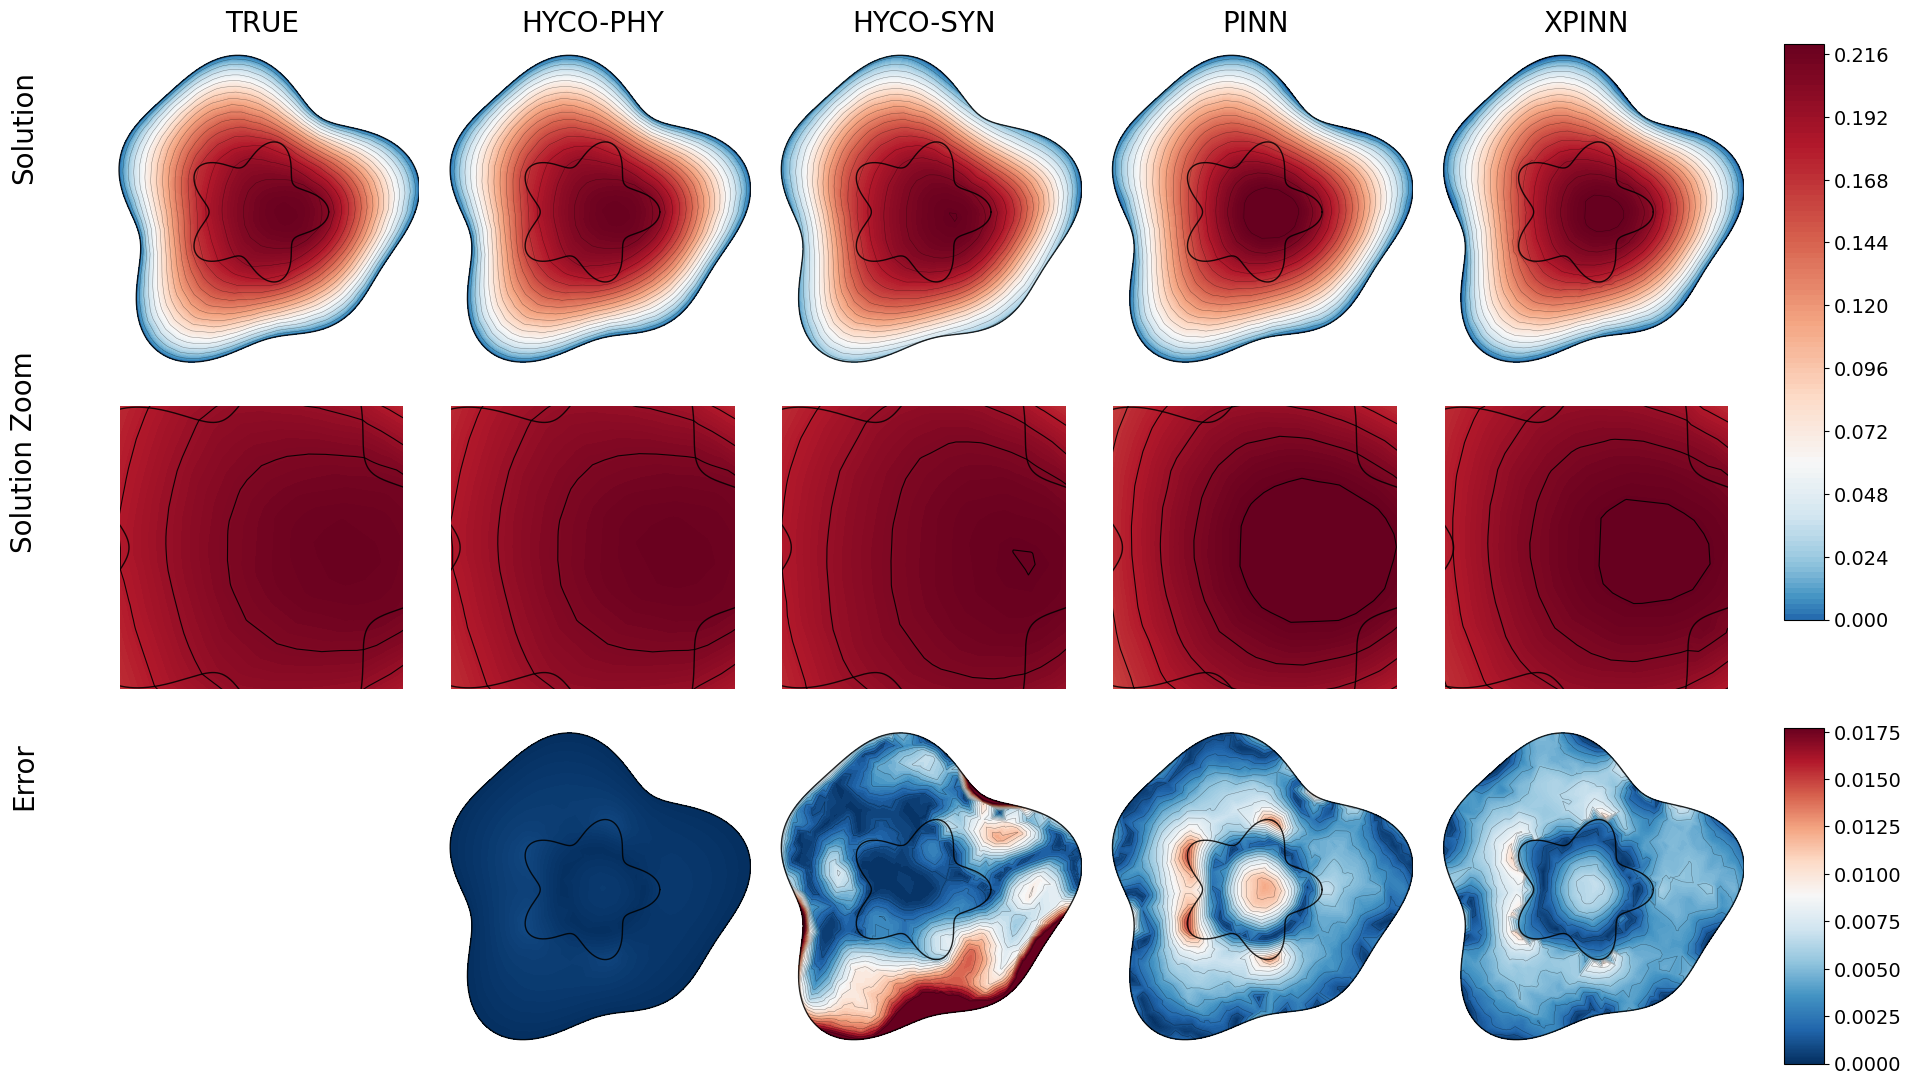

Figure saved as Ex1_solution_zoom_error_noise_0.00.png and .pdf in ./results_elliptic2/


In [40]:
# =====================================================================
# Figure 1: Solution (global), Solution Zoom, and Error (linear norm)
# =====================================================================
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize, PowerNorm
from matplotlib.cm import ScalarMappable
import numpy as np
import matplotlib.pyplot as plt

NOISE_TO_PLOT = 0.00

# Load results (assuming load_result and other variables exist)
try:
    hyco_res = load_result('hyco', NOISE_TO_PLOT)
    print("HYCO loaded.")
except FileNotFoundError:
    raise RuntimeError(f"HYCO result for η={NOISE_TO_PLOT:.2f} not found.")

try:
    pinn_res = load_result('pinn', 0.00)
    print("PINN loaded.")
except FileNotFoundError:
    raise RuntimeError("PINN result not found. Run Cell 8 first.")

try:
    xpinn_res = load_result('xpinn', 0.00)
    print("XPINN loaded.")
except FileNotFoundError:
    raise RuntimeError("XPINN result not found. Run Cell 9 first.")

# Method order
method_order = ["TRUE", "HYCO-PHY", "HYCO-SYN", "PINN", "XPINN"]

# Solution data
sol_data = {
    "TRUE": u_true,
    "HYCO-PHY": hyco_res.u_phy,
    "HYCO-SYN": hyco_res.u_syn,
    "PINN": pinn_res.u,
    "XPINN": xpinn_res.u,
}

# Error data (absolute error vs true solution)
err_data = {
    "TRUE": np.zeros_like(u_true),
    "HYCO-PHY": np.abs(hyco_res.u_phy - u_true),
    "HYCO-SYN": np.abs(hyco_res.u_syn - u_true),
    "PINN": np.abs(pinn_res.u - u_true),
    "XPINN": np.abs(xpinn_res.u - u_true),
}

# Color limits for solutions (global)
all_sol = np.concatenate([sol_data[name] for name in method_order])
vmin_sol = np.percentile(all_sol, 1)
vmax_sol = np.percentile(all_sol, 99)
norm_sol = PowerNorm(gamma=0.55, vmin=vmin_sol, vmax=vmax_sol)

# Color limits for errors (linear, vmin=0, vmax=98% percentile)
all_err_non_true = np.concatenate([err_data[name] for name in method_order if name != "TRUE"])
vmax_err = np.percentile(all_err_non_true, 98) if np.max(all_err_non_true) > 0 else 1.0
vmin_err = 0.0
norm_err = Normalize(vmin=vmin_err, vmax=vmax_err)

# Contour levels for solutions
N_LINE = 18
line_levels_sol = np.linspace(vmin_sol, vmax_sol, N_LINE)
line_levels_err = np.linspace(vmin_err, vmax_err, N_LINE)
N_FILL = 120

# Zoom region
ZOOM_XLIM = (-0.35, 0.35)
ZOOM_YLIM = (-0.35, 0.35)

# Create figure with 3 rows, 5 columns
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(3, 5, wspace=0.05, hspace=0.06,
                       height_ratios=[1, 0.8, 1])

ax_sol_glob = [fig.add_subplot(gs[0, j]) for j in range(5)]
ax_sol_zoom = [fig.add_subplot(gs[1, j]) for j in range(5)]
ax_err = [fig.add_subplot(gs[2, j]) for j in range(5)]

# Plotting helper for global solution
def plot_global(ax, data, title, norm, line_levels, cmap="RdBu_r"):
    cf = ax.tricontourf(triangulation, data, levels=N_FILL,
                        cmap=cmap, norm=norm)
    ax.tricontour(triangulation, data, levels=line_levels,
                  colors="k", linewidths=0.32, alpha=0.45)
    overlay_boundaries(ax)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=20)
    ax.axis("off")
    return cf

def plot_zoom(ax, data, norm, line_levels, xlim, ylim, cmap="RdBu_r"):
    cf = ax.tricontourf(triangulation, data, levels=N_FILL,
                        cmap=cmap, norm=norm)
    ax.tricontour(triangulation, data, levels=line_levels,
                  colors="k", linewidths=0.8, alpha=0.9)
    overlay_boundaries(ax)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    ax.axis("off")
    return cf

def plot_err(ax, data, norm, line_levels, cmap="RdBu_r"):
    cf = ax.tricontourf(triangulation, data, levels=N_FILL,
                        cmap=cmap, norm=norm)
    ax.tricontour(triangulation, data, levels=line_levels,
                  colors="k", linewidths=0.32, alpha=0.45)
    overlay_boundaries(ax)
    ax.set_aspect("equal")
    ax.axis("off")
    return cf

# Fill global solution row
cf_sol_glob = []
for j, name in enumerate(method_order):
    cf = plot_global(ax_sol_glob[j], sol_data[name], name, norm_sol, line_levels_sol)
    cf_sol_glob.append(cf)

# Fill solution zoom row
for j, name in enumerate(method_order):
    plot_zoom(ax_sol_zoom[j], sol_data[name], norm_sol, line_levels_sol,
              ZOOM_XLIM, ZOOM_YLIM)

# Fill error row (skip TRUE, which is all zeros)
cf_err = []
for j, name in enumerate(method_order):
    if name == "TRUE":
        ax_err[j].axis('off')
        cf_err.append(None)
    else:
        cf = plot_err(ax_err[j], err_data[name], norm_err, line_levels_err)
        cf_err.append(cf)

# Adjust layout and colorbars
fig.subplots_adjust(right=0.88, left=0.06, bottom=0.08, top=0.94)

# Colorbar for solutions
cbar_ax_sol = fig.add_axes([0.90, 0.45, 0.02, 0.48])
cbar_sol = fig.colorbar(cf_sol_glob[0], cax=cbar_ax_sol)
cbar_sol.ax.tick_params(labelsize=14)

# Colorbar for errors
sm_err = ScalarMappable(norm=norm_err, cmap='RdBu_r')
sm_err.set_array([])
cbar_ax_err = fig.add_axes([0.90, 0.08, 0.02, 0.28])
cbar_err = fig.colorbar(sm_err, cax=cbar_ax_err)
cbar_err.ax.tick_params(labelsize=14)

# Row labels
row_labels = ["Solution", "Solution Zoom", "Error"]
y_positions = [0.86, 0.59, 0.32]
for label, y in zip(row_labels, y_positions):
    fig.text(0.02, y, label, rotation='vertical',
             va='center', ha='center', fontsize=20)

# Save
save_name = f"Ex1_solution_zoom_error_noise_{NOISE_TO_PLOT:.2f}"
plt.savefig(os.path.join(SAVE_DIR, save_name + ".png"), dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig(os.path.join(SAVE_DIR, save_name + ".pdf"), dpi=600, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Figure saved as {save_name}.png and .pdf in {SAVE_DIR}")

HYCO loaded.
PINN loaded.
XPINN loaded.


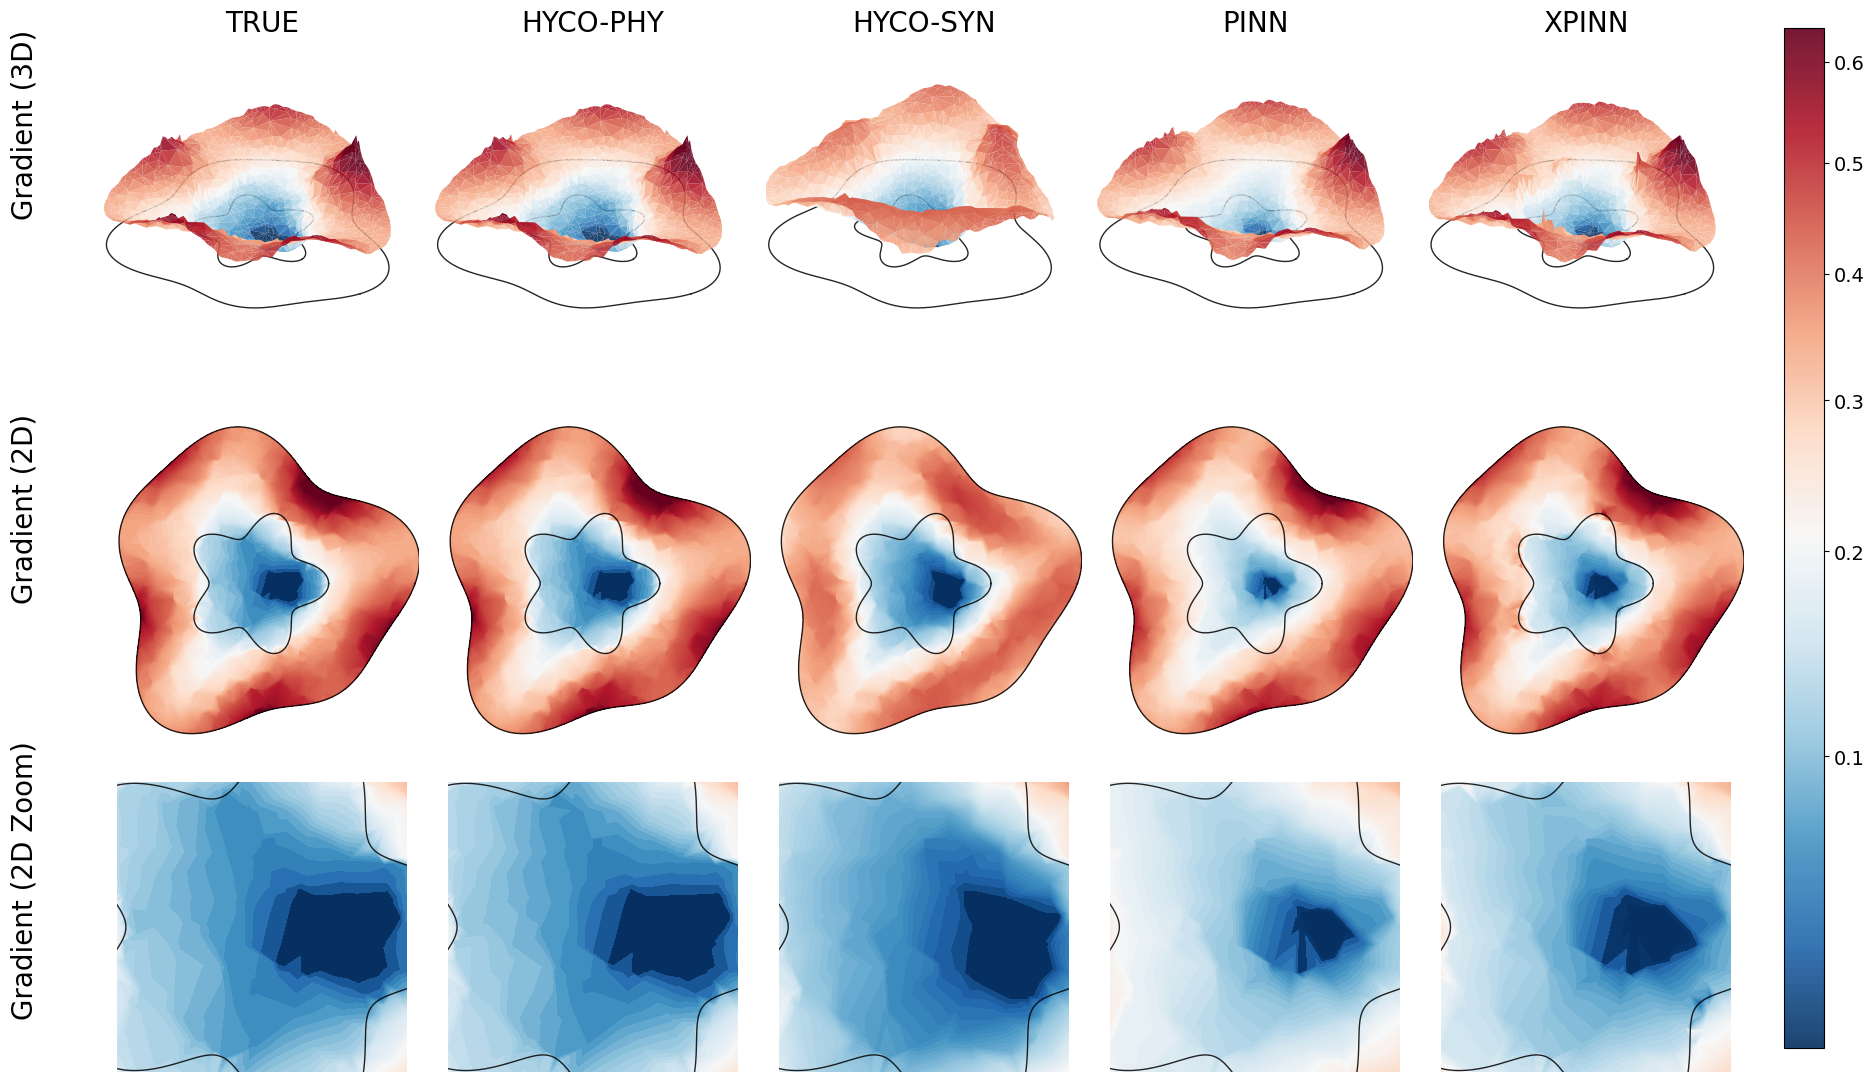

Figure saved as Ex1_gradient_3d_2d_zoom_noise_0.00.png and .pdf in ./results_elliptic2/


In [33]:
# =====================================================================
# Figure 2: Gradient magnitude: 3D (global), 2D (global), 2D zoom
# =====================================================================
import matplotlib.gridspec as gridspec
from matplotlib.colors import PowerNorm, Normalize
from matplotlib.cm import ScalarMappable
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # required for 3D projection

NOISE_TO_PLOT = 0.00

# Load results (assuming load_result and other variables exist)
try:
    hyco_res = load_result('hyco', NOISE_TO_PLOT)
    print("HYCO loaded.")
except FileNotFoundError:
    raise RuntimeError(f"HYCO result for η={NOISE_TO_PLOT:.2f} not found.")

try:
    pinn_res = load_result('pinn', 0.00)
    print("PINN loaded.")
except FileNotFoundError:
    raise RuntimeError("PINN result not found. Run Cell 8 first.")

try:
    xpinn_res = load_result('xpinn', 0.00)
    print("XPINN loaded.")
except FileNotFoundError:
    raise RuntimeError("XPINN result not found. Run Cell 9 first.")

# Gradient magnitude function
def gradient_magnitude_on_nodes(points, triangles, u):
    grad_x = np.zeros(len(points))
    grad_y = np.zeros(len(points))
    weights = np.zeros(len(points))
    for tri in triangles:
        p0 = points[tri[0]]
        p1 = points[tri[1]]
        p2 = points[tri[2]]
        x0, y0 = p0
        x1, y1 = p1
        x2, y2 = p2
        det = (x1-x0)*(y2-y0) - (x2-x0)*(y1-y0)
        if abs(det) < 1e-12:
            continue
        u0, u1, u2 = u[tri[0]], u[tri[1]], u[tri[2]]
        ux = ((u1-u0)*(y2-y0) - (u2-u0)*(y1-y0)) / det
        uy = ((u2-u0)*(x1-x0) - (u1-u0)*(x2-x0)) / det
        area = 0.5 * abs(det)
        for i in tri:
            grad_x[i] += ux * area
            grad_y[i] += uy * area
            weights[i] += area
    weights = np.maximum(weights, 1e-12)
    grad_x /= weights
    grad_y /= weights
    return np.sqrt(grad_x**2 + grad_y**2)

# Compute gradients
grad_true = gradient_magnitude_on_nodes(points, triangles, u_true)
grad_pinn = gradient_magnitude_on_nodes(points, triangles, pinn_res.u)
grad_hyco_phy = gradient_magnitude_on_nodes(points, triangles, hyco_res.u_phy)
grad_hyco_syn = gradient_magnitude_on_nodes(points, triangles, hyco_res.u_syn)
grad_xpinn = gradient_magnitude_on_nodes(points, triangles, xpinn_res.u)

# Data dictionaries
method_order = ["TRUE", "HYCO-PHY", "HYCO-SYN", "PINN", "XPINN"]
grad_data = {
    "TRUE": grad_true,
    "HYCO-PHY": grad_hyco_phy,
    "HYCO-SYN": grad_hyco_syn,
    "PINN": grad_pinn,
    "XPINN": grad_xpinn,
}

# Color limits (global for gradients)
all_grad = np.concatenate([grad_data[name] for name in method_order])
vmin_grad = np.percentile(all_grad, 1)
vmax_grad = np.percentile(all_grad, 99)
norm_grad = PowerNorm(gamma=0.55, vmin=vmin_grad, vmax=vmax_grad)

# Zoom region
ZOOM_XLIM = (-0.35, 0.35)
ZOOM_YLIM = (-0.35, 0.35)

# Helper to overlay boundaries in 3D (z=0)
def overlay_boundaries_3d(ax):
    th = np.linspace(0, 2*np.pi, 1000)
    outer = np.column_stack([outer_radius(th)*np.cos(th), outer_radius(th)*np.sin(th)])
    inner = np.column_stack([interface_radius(th)*np.cos(th), interface_radius(th)*np.sin(th)])
    ax.plot(outer[:,0], outer[:,1], 0, color='black', lw=1.0, alpha=0.85)
    ax.plot(inner[:,0], inner[:,1], 0, color='black', lw=1.0, alpha=0.85)

# Helper for 2D overlay (no z component)
def overlay_boundaries_2d(ax):
    th = np.linspace(0, 2*np.pi, 1000)
    outer = np.column_stack([outer_radius(th)*np.cos(th), outer_radius(th)*np.sin(th)])
    inner = np.column_stack([interface_radius(th)*np.cos(th), interface_radius(th)*np.sin(th)])
    ax.plot(outer[:,0], outer[:,1], color='black', lw=1.0, alpha=0.85)
    ax.plot(inner[:,0], inner[:,1], color='black', lw=1.0, alpha=0.85)

# Create figure with 3 rows: 3D, 2D global, 2D zoom
fig = plt.figure(figsize=(20, 12))                     # 画布更大
gs = gridspec.GridSpec(3, 5, wspace=0.05, hspace=0.06,  # 间距更紧凑
                       height_ratios=[1, 1, 0.8])    # 3D行更高

ax_grad_3d = [fig.add_subplot(gs[0, j], projection='3d') for j in range(5)]
ax_grad_2d = [fig.add_subplot(gs[1, j]) for j in range(5)]
ax_grad_2d_zoom = [fig.add_subplot(gs[2, j]) for j in range(5)]

# Plotting function for 3D
def plot_grad_3d(ax, data, title, norm, cmap="RdBu_r", elev=35, azim=-45):
    surf = ax.plot_trisurf(points[:,0], points[:,1], data,
                           triangles=triangles, cmap=cmap, norm=norm,
                           edgecolor='none', alpha=0.9)
    overlay_boundaries_3d(ax)
    #ax.set_aspect('equal')
    ax.set_box_aspect((1, 1, 0.35), zoom=1.4)
    ax.set_title(title, fontsize=20)
    ax.axis('off')
    ax.view_init(elev=elev, azim=azim)
    return surf

# Plotting function for 2D global
def plot_grad_2d(ax, data, norm, cmap="RdBu_r"):
    cf = ax.tricontourf(triangulation, data, levels=120, cmap=cmap, norm=norm)
    overlay_boundaries_2d(ax)
    ax.set_aspect('equal')
    ax.axis('off')
    return cf

# Plotting function for 2D zoom
def plot_grad_2d_zoom(ax, data, norm, xlim, ylim, cmap="RdBu_r"):
    cf = ax.tricontourf(triangulation, data, levels=120, cmap=cmap, norm=norm)
    overlay_boundaries_2d(ax)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')
    ax.axis('off')
    return cf

# Fill rows
surf_3d = []
cf_2d = []
cf_2d_zoom = []

for j, name in enumerate(method_order):
    # 3D row
    surf = plot_grad_3d(ax_grad_3d[j], grad_data[name], name, norm_grad)
    surf_3d.append(surf)
    # 2D global row
    cf = plot_grad_2d(ax_grad_2d[j], grad_data[name], norm_grad)
    cf_2d.append(cf)
    # 2D zoom row
    cfz = plot_grad_2d_zoom(ax_grad_2d_zoom[j], grad_data[name], norm_grad,
                            ZOOM_XLIM, ZOOM_YLIM)
    cf_2d_zoom.append(cfz)

# Adjust layout and colorbar (using the 3D surf as reference)
fig.subplots_adjust(right=0.88, left=0.06, bottom=0.06, top=0.94)

cbar_ax_grad = fig.add_axes([0.90, 0.08, 0.02, 0.85])
cbar_grad = fig.colorbar(surf_3d[0], cax=cbar_ax_grad)
cbar_grad.ax.tick_params(labelsize=14)

# Row labels
row_labels = ["Gradient (3D)", "Gradient (2D)", "Gradient (2D Zoom)"]
y_positions = [0.85, 0.53, 0.22]
for label, y in zip(row_labels, y_positions):
    fig.text(0.02, y, label, rotation='vertical',
             va='center', ha='center', fontsize=20)

# Save
save_name = f"Ex1_gradient_3d_2d_zoom_noise_{NOISE_TO_PLOT:.2f}"
plt.savefig(os.path.join(SAVE_DIR, save_name + ".png"), dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig(os.path.join(SAVE_DIR, save_name + ".pdf"), dpi=600, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Figure saved as {save_name}.png and .pdf in {SAVE_DIR}")